# Plotnine - geom-s and stat-s

## Introduction

This is a continuing investigation of __plotnine__, to further understand the underlying concepts. Many examples will be provided.



## geom and stat concepts


The official description of the __goem__ and __stat__ concepts are:

    Statistical transformations (stats) do aggregations and other computations on data before it is drawn out. stat_* determine the type of computation done on the data. Different types of computations yield varied results, so a stat must be paired with a geom that can represent all or some of the computations.

and 

    Geometric objects (geoms) are responsible for the visual representation of data points. geom_* classes determine the kind of geometric objects and every plot must have at least one geom added to it. 



-------------------
## Implementation

### Imports
-  warnings can be used to supress annoying __plotnine__ missing data messages
-  numpy does vectorised numerical calulations
-  pandas manages dataframe
-  plotnine - the main actor in this drama

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotnine as p9
from scipy import stats

__watermark__ provides reproducability information

In [2]:
%load_ext watermark

In [3]:
# warnings.filterwarnings("ignore", category=UserWarning, module="plotnine.*")

-------------------

## geom and stat concepts


To  repeat, the official description of the __goem__ and __stat__ concepts are:

    Statistical transformations (stats) do aggregations and other computations on data before it is drawn out. stat_* determine the type of computation done on the data. Different types of computations yield varied results, so a stat must be paired with a geom that can represent all or some of the computations.

and 

    Geometric objects (geoms) are responsible for the visual representation of data points. geom_* classes determine the kind of geometric objects and every plot must have at least one geom added to it. 

There is a mutual relationship between the two.  A __geom__ has an associated statistical process  (a __stat__), and a __stat__ has an associated method of visualization (a __geom__).  If you call a __geom__, it will call a __stat__ before crteating a graphic visualization; if you call a __stat__, it will call a __geom__ to render a visualization of the data processing results.

We can make this explicit with an example.

First we generate 1,000 normal random numbers

In [4]:
size = 1000
x = np.random.normal(0, 10, size)

### geom referencing a stat

Now, we create a histogram with a __geom__ (geom_histogram) that has a default statistical process of binning data, and counting the entries in each bin.  Now __stat_bin__ is the default statistical process for histogram, but we make this explicit by the __stat=__ parameter.  __plotnine__ takes this parameter, glues "stat_" on the front, and trhen calls that function.  The __mapping=__ parameter tells plotnine to get the x values from the x array and map them to the x-axis of the plot.

The steps  are:
- create an empty plot
- add a histogram, setting the line color to gray to make the bars stand out
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


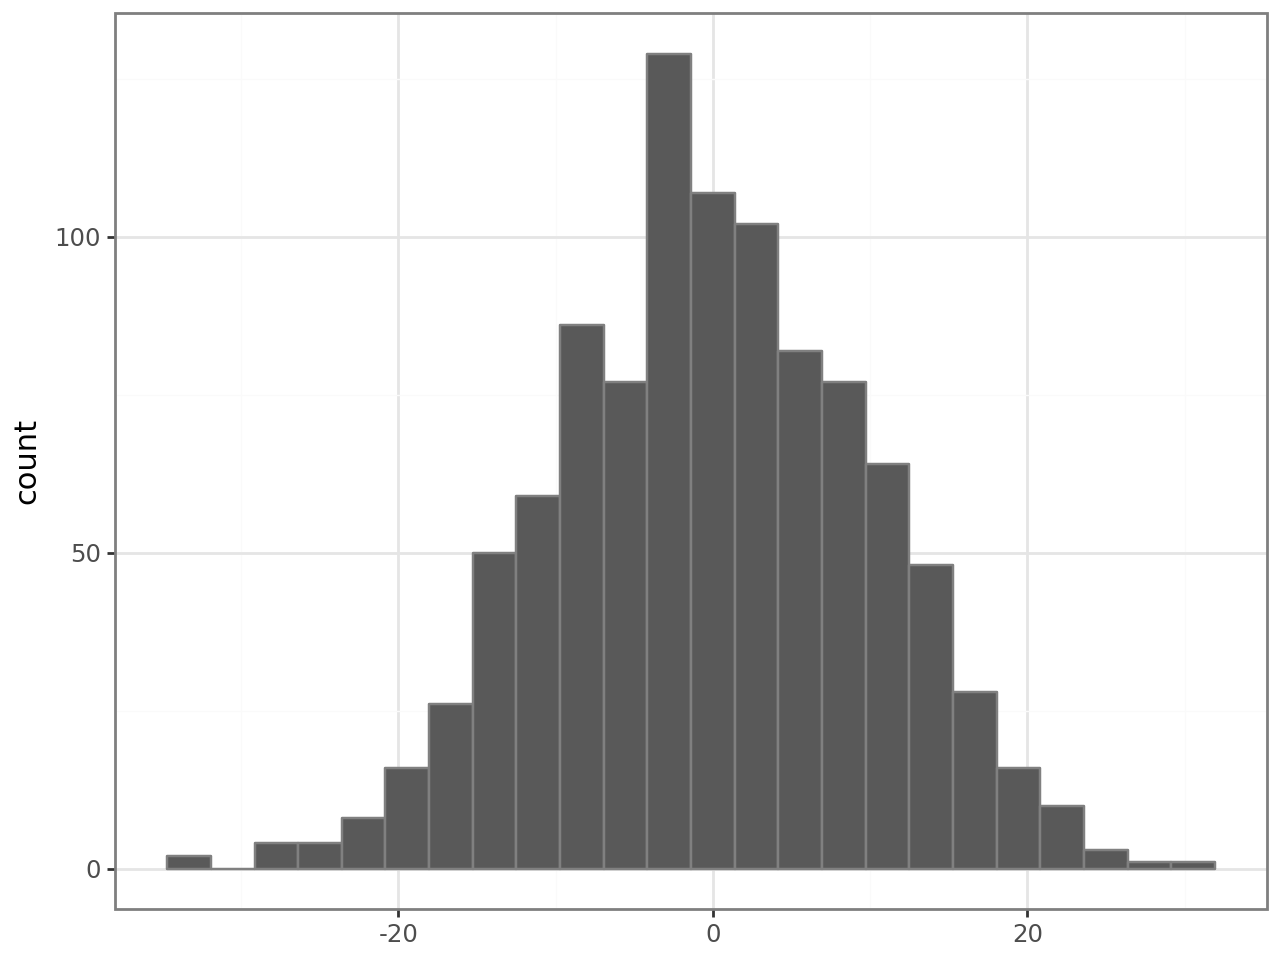

In [5]:
plot = (
    p9.ggplot()
    + p9.geom_histogram(mapping=p9.aes(x=x), color="gray", stat="bin")
    + p9.theme_bw()
)
plot

### stat referencing a geom

We can get exactly the same plot by invoking the statistical process, and specifying we want a histogram visualization

The steps  are:
- create an empty plot
- call for a binning statistical process, which (by default) will add a histogram.  The line color parameter is passed onto the __geom__
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


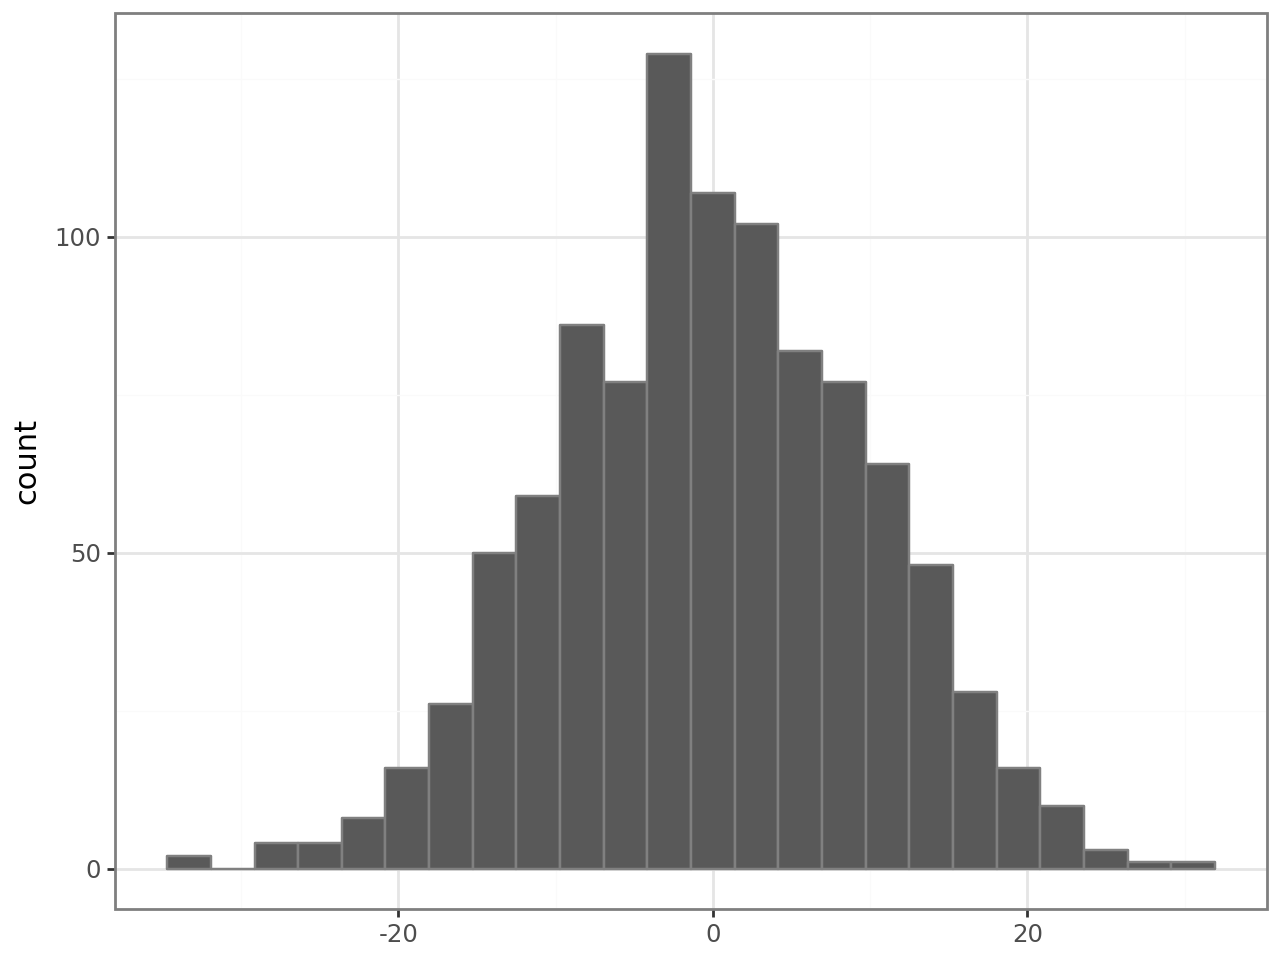

In [6]:
plot = (
    p9.ggplot()
    + p9.stat_bin(mapping=p9.aes(x=x), color="gray", geom="histogram")
    + p9.theme_bw()
)
plot

We can reference a __goem__ that isn't the default __geom__.  In the case below, we ask to visualize the results of the statistical operation with points

The steps  are:
- create an empty plot
- call for a binning statistical process, and specify visualization by points. In this case, the color parameter is passed to the __geom__ to set the point color
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


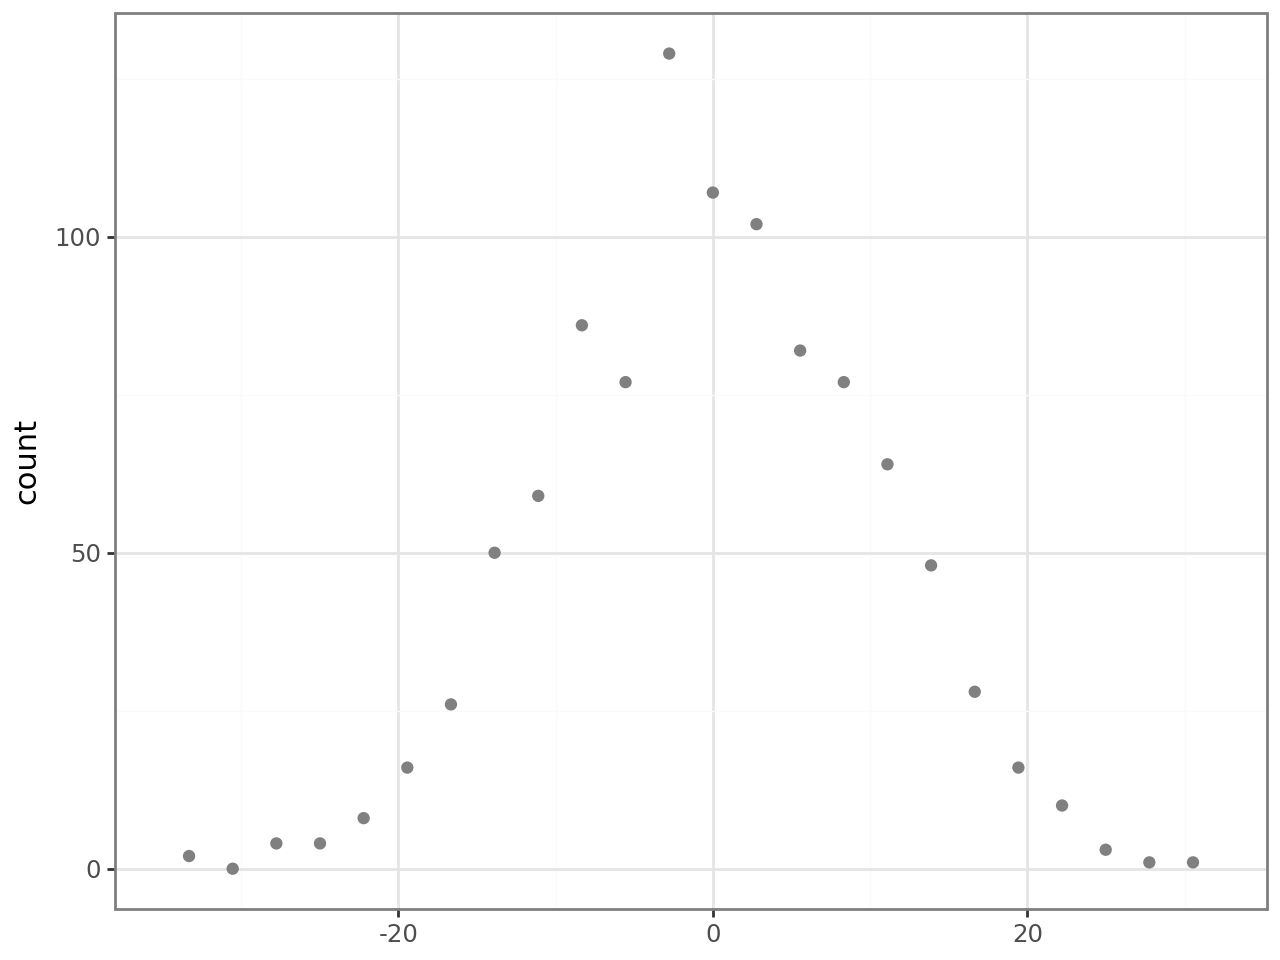

In [7]:
plot = (
    p9.ggplot()
    + p9.stat_bin(mapping=p9.aes(x=x), color="gray", geom="point")
    + p9.theme_bw()
)
plot

In the case below, we ask to visualize the results of the statistical operation as a line

The steps  are:
- create an empty plot
- call for a binning statistical process, and specify visualization by a line
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


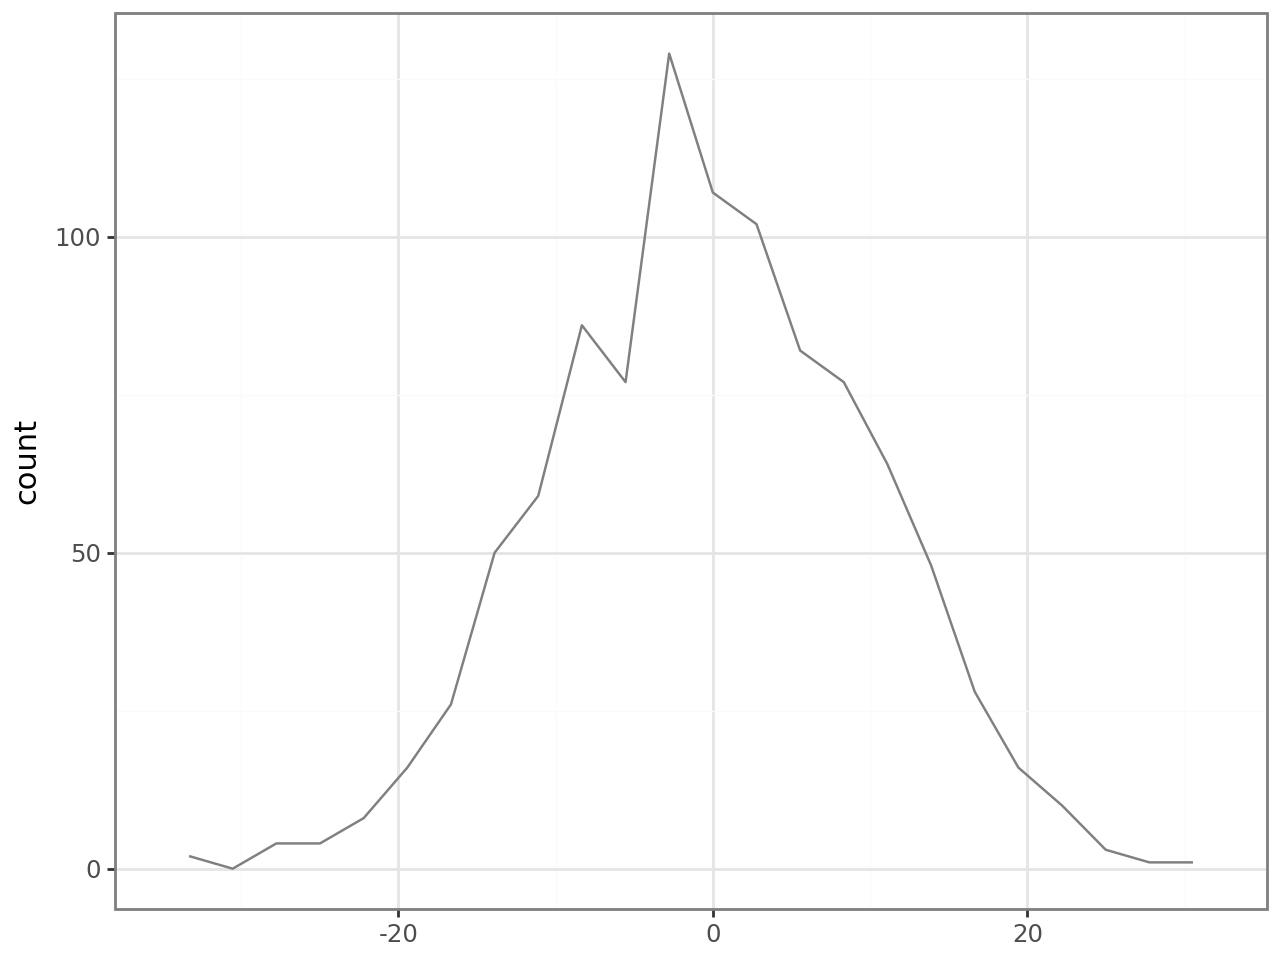

In [8]:
plot = (
    p9.ggplot()
    + p9.stat_bin(
        mapping=p9.aes(
            x=x,
        ),
        color="gray",
        geom="line",
    )
    + p9.theme_bw()
)
plot

This only works is the target __geom__ gets all the data it needs.  In the example below,we feed the count of points in each bin to the label __aes__ parameter required by __geom_label__.  The binning process doesn't ever use the label parameter, but it is passed onto __geom_label__ which does use it.

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


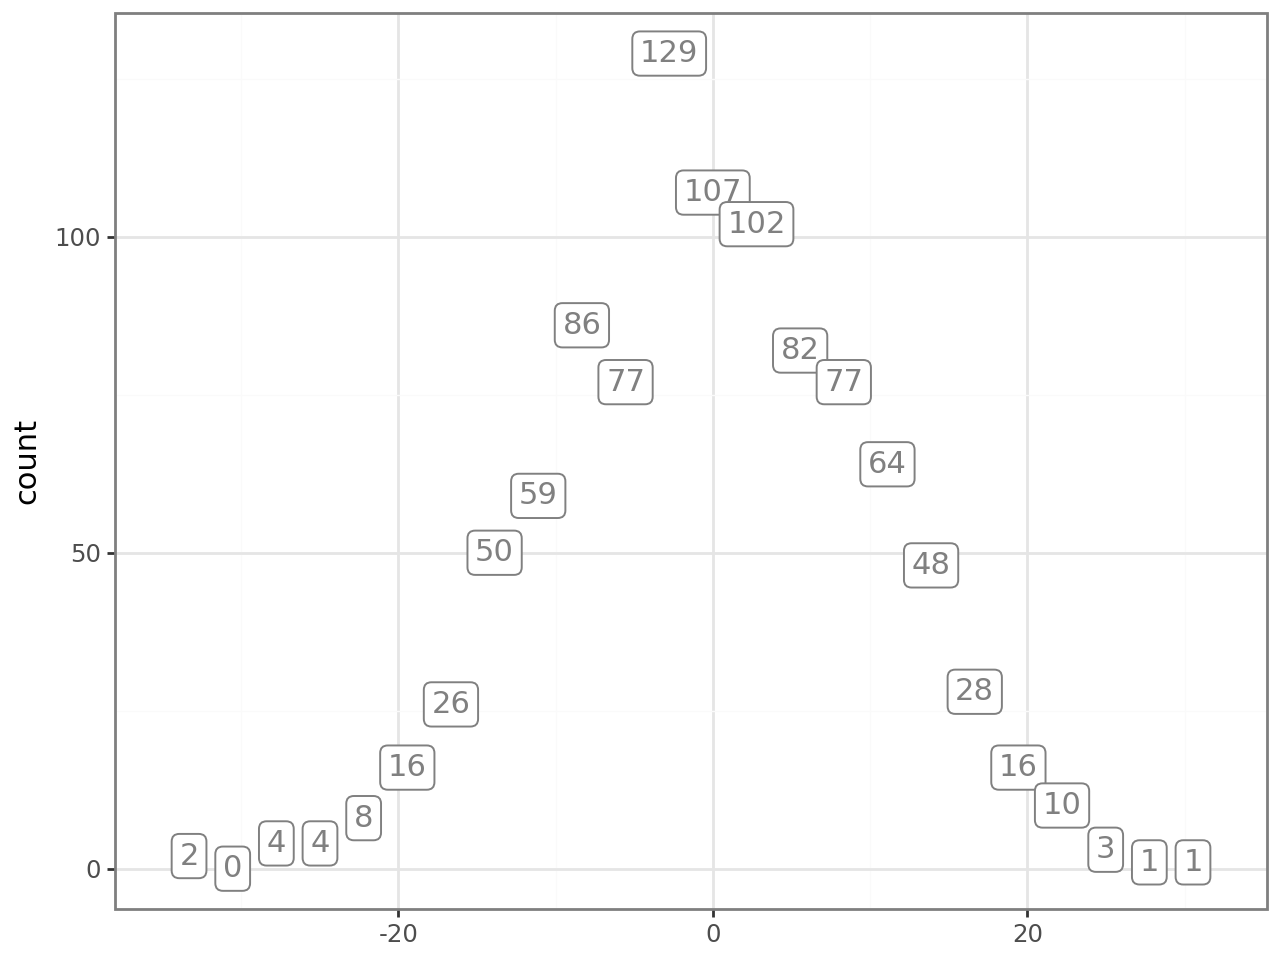

In [9]:
plot = (
    p9.ggplot()
    + p9.stat_bin(
        mapping=p9.aes(x=x, label=p9.after_stat("count")),
        color="gray",
        geom="label",
        format_string="{:.0f}",
    )
    + p9.theme_bw()
)
plot

It can work the other way (invoke a __stat__ from a __geom__, and use the results of the statistical processing in the __geom__).  Each __stat__ may create pseudo-variables that can be accessed in the parameters of the __geom__ call.

For example, __stat_bin__ creates:

    Options for computed aesthetics

    - "count"    # number of points in bin
    - "density"  # density of points in bin, scaled to integrate to 1
    - "ncount"   # count, scaled to maximum of 1
    - "ndensity" # density, scaled to maximum of 1
    - "ngroup"   # number of points in group

So here we can use the __after_stat__ function to access these variable by name, and specify that we want a plot layer consisting of labels:  the x array is mapped to x-axis position, the after-statistical processing count of values in each bin is mapped to the y-axis position, and the count of values in each bin is mapped to the label to show.

The steps  are:
- create an empty plot
- create labels with a call  for a binning statistical process, setting labels content after the statistical process from thye pseudo-variable "count"
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


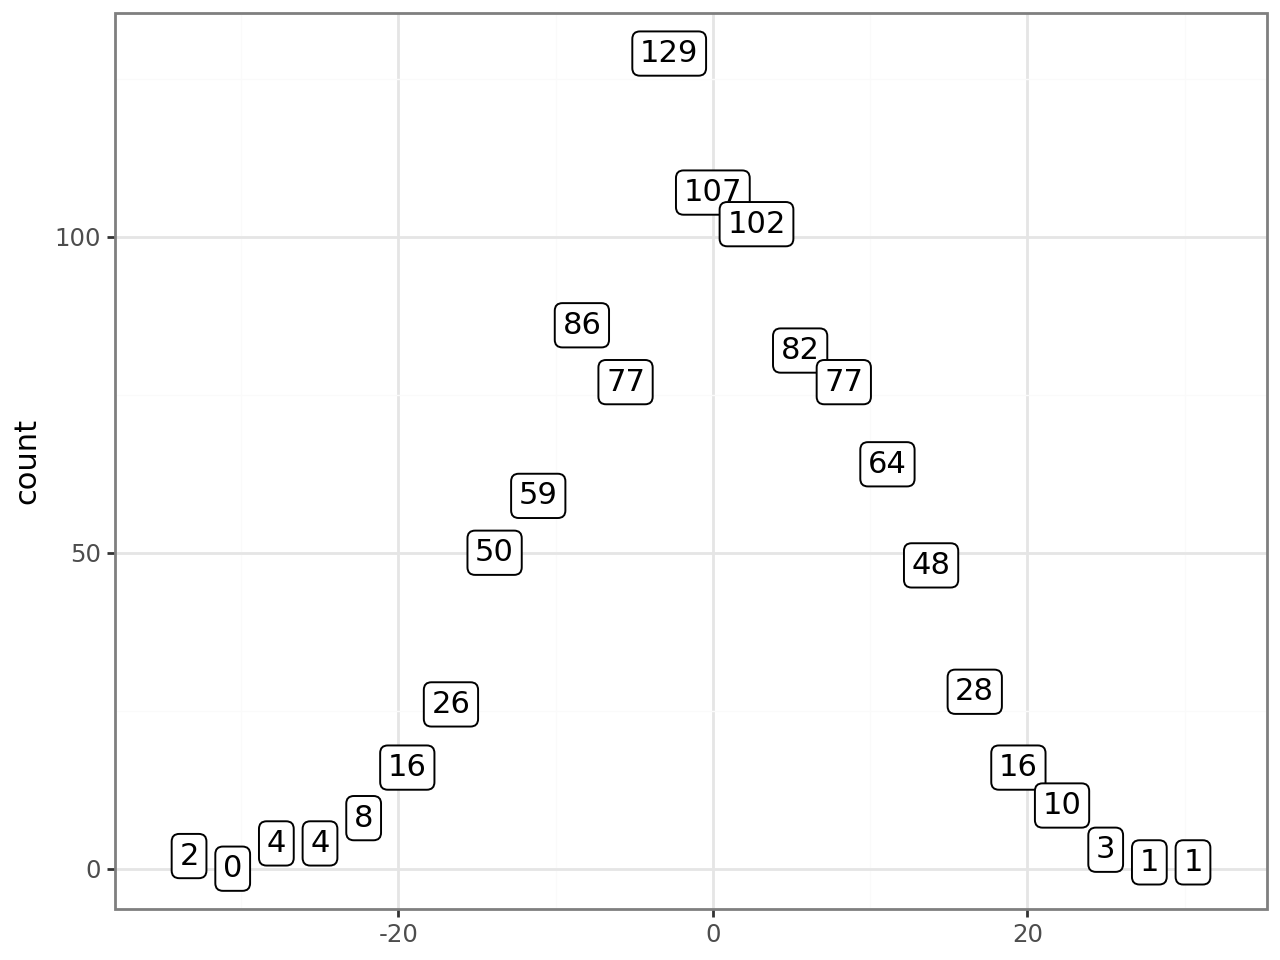

In [10]:
plot = (
    p9.ggplot()
    + p9.geom_label(
        mapping=p9.aes(x=x, y=p9.after_stat("count"), label=p9.after_stat("count")),
        stat="bin",
        format_string="{:.0f}",
    )
    + p9.theme_bw()
)
plot

As another example, we show labels holding  the normalized count (maximum=1),  another pseudo variable computed the __stat_bin__.

The steps  are:
- create an empty plot
- create labels with a call  for a binning statistical process, setting labels content after the statistical process to normalized counts
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


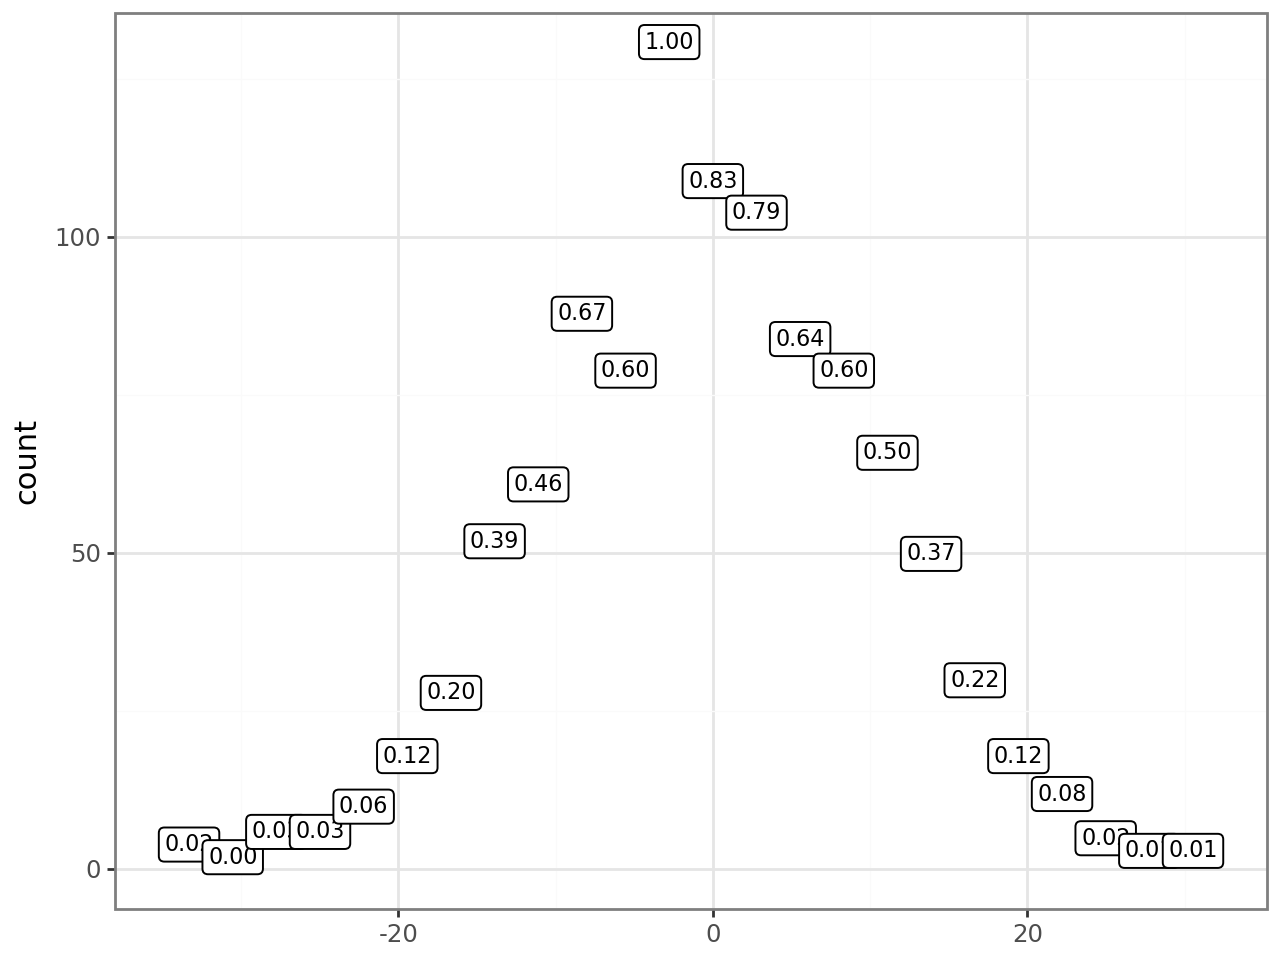

In [11]:
plot = (
    p9.ggplot()
    + p9.geom_label(
        mapping=p9.aes(x=x, y=p9.after_stat("count"), label=p9.after_stat("ncount")),
        stat="bin",
        format_string="{:.2f}",
        size=8,
        va="bottom",
    )
    + p9.theme_bw()
)
plot

-----------------

### More on computed pseudo-variables  

Plotnine call these pseudo-variables "computed aesthetics".

We set up a __pandas__ dataframe, with a single column "var1"

In [12]:
df = pd.DataFrame({"var1": [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6]})

Create a vertical bar chart, with the count how many time each value  occurs mapped to the y-axis (i.e. the top of the bar). Note we are using __stat_count__ (by default), which is different to __stat_bin__, which counts values falling into each bin.

The pseudo-variables for __stat_count__ are:

    Options for computed aesthetics
    
    - "count"  # Number of observations at a position
    - "prop"   # Ratio of points in the panel at a position

In the example below, we use the psedo-variable "count" to set the height (y value) of each bar

The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting
- set theme to black & white

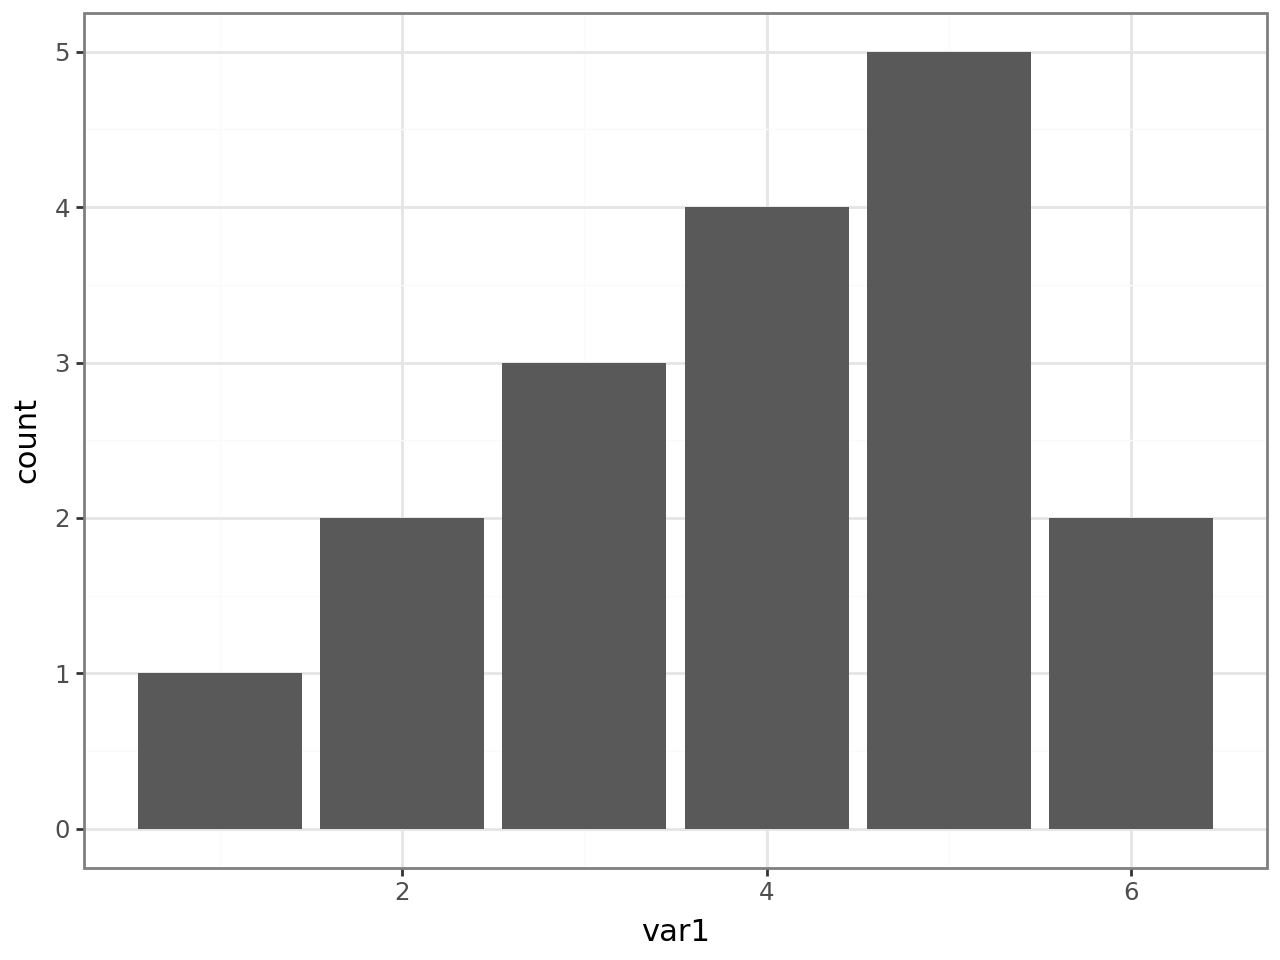

In [13]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count"),
        ),
    )
    + p9.theme_bw()
)
plot

In the example below, we show how we can use expressions operating 
on the pseudo-variables in the mapping to plot parameters.  Of course, we could have used the pseudo-variable "prop", but that is not the point of the example.  We could have squared __count__, or taken the square root, etc.

The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting in a formulae that plotnine will evaluate
- set theme to black & white

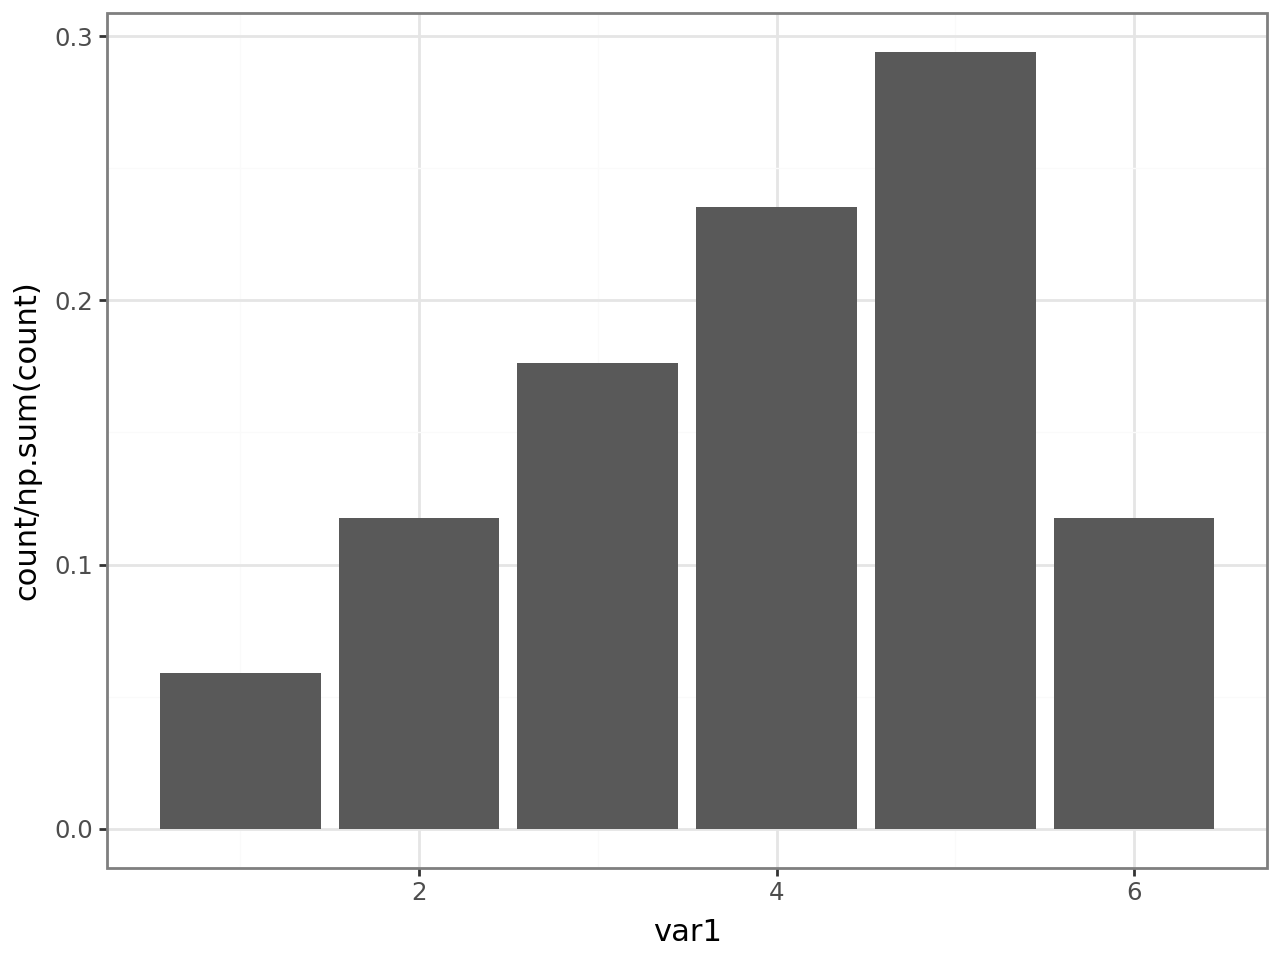

In [14]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count/np.sum(count)"),
        )
    )
    + p9.theme_bw()
)
plot

### Some stats trash original __aes__ mappings

In the example below, we map __var1__ to the x-axis, y_axis, and color of each point.  The __stat__ __geom_point__ calls by default is __stat_identity__, the "do-nothing" __stat__.  Thus the multiple mappings work.

The steps  are:
- create an empty plot, specifying the source dataframe
- create points colored according to x value
- set theme to black & white

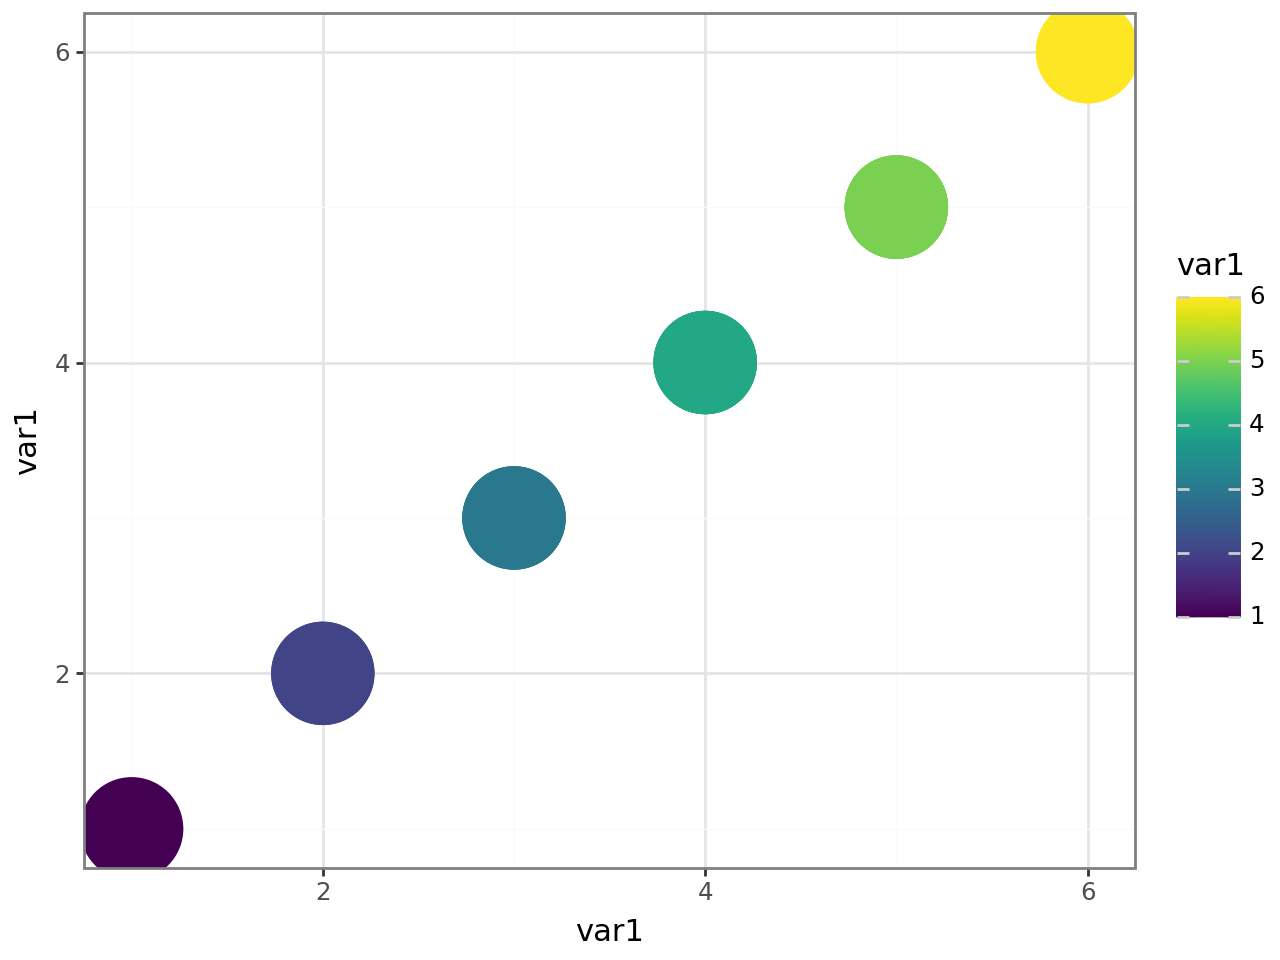

In [15]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(
            x="var1",
            y="var1",
            color="var1",
        ),
        size=20,
    )
    + p9.theme_bw()
)
plot

In the example below , __geom_bar__ calls __stat_count__, and as a result, the original __aes__ mappings are lost: so assigning the variable "var1" to fill (to set the color) fails: even worse, it fails silently!

The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting in a formulae that plotnine will evaluate. We try to set the fill according to the original variable names from the dataframe (Fail!)
- set theme to black & white

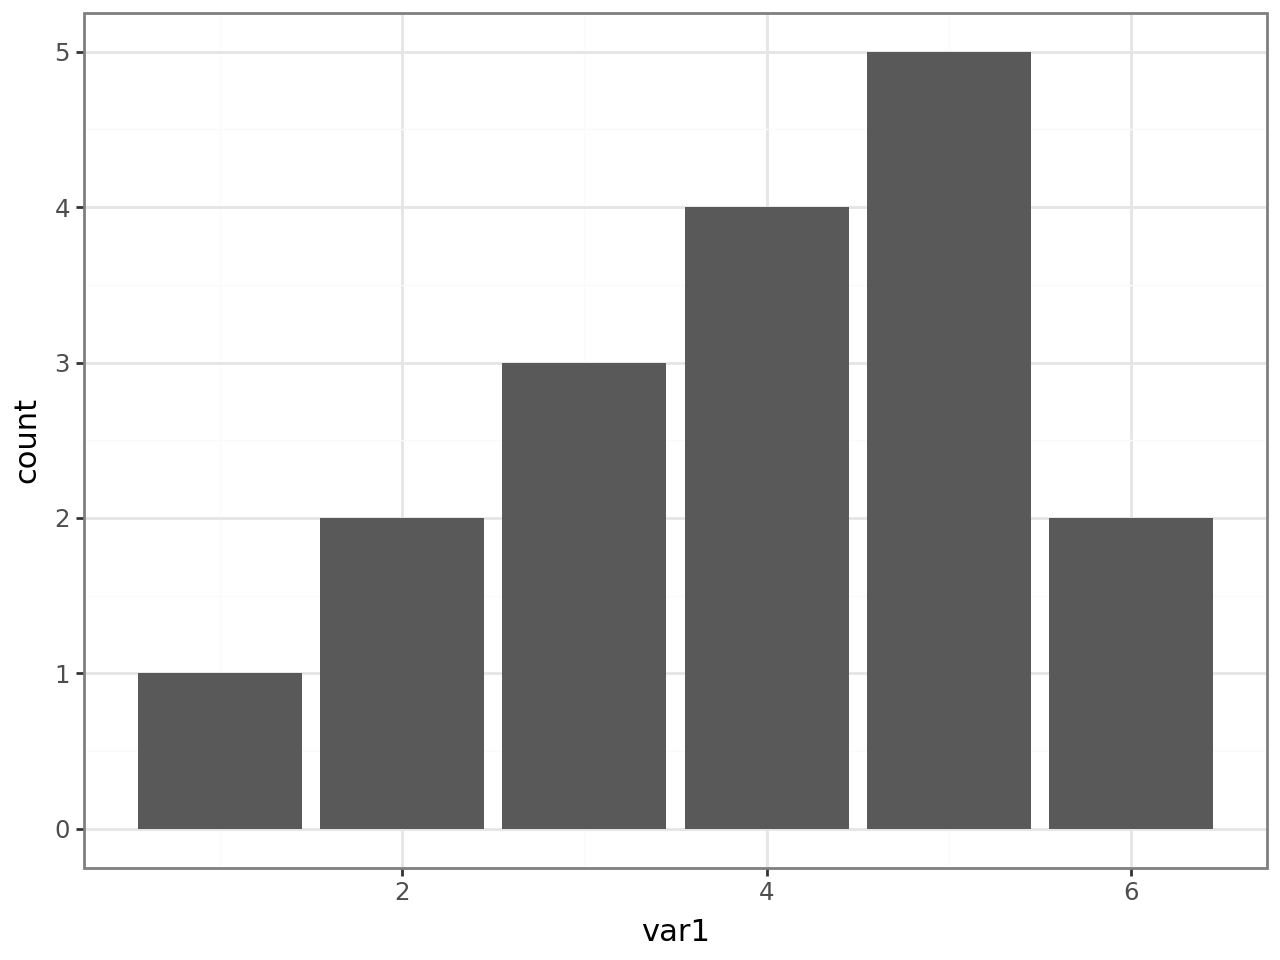

In [16]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count"),
            fill="var1",
        ),
    )
    + p9.theme_bw()
)
plot

However, in the new __aes__ environment after the __stat_count__ operations, we have the aesthetic variable "x" and "y" defined.  Another way to think about it is that we have forgotten about the dataframe that was our original source of data, and are now operating the after-statistical-processing regime, where we can use pseudo-variable defined by the process.  So we can use "x" (holding the values that came from the "var1" column in the source dataframe) to map to the fill value

This gives us what we want: a gradient of colors for the bars


The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting in a formulae that plotnine will evaluate. We try to set the fill according to one of the after-process pseudo-variable names (Works!)
- set theme to black & white

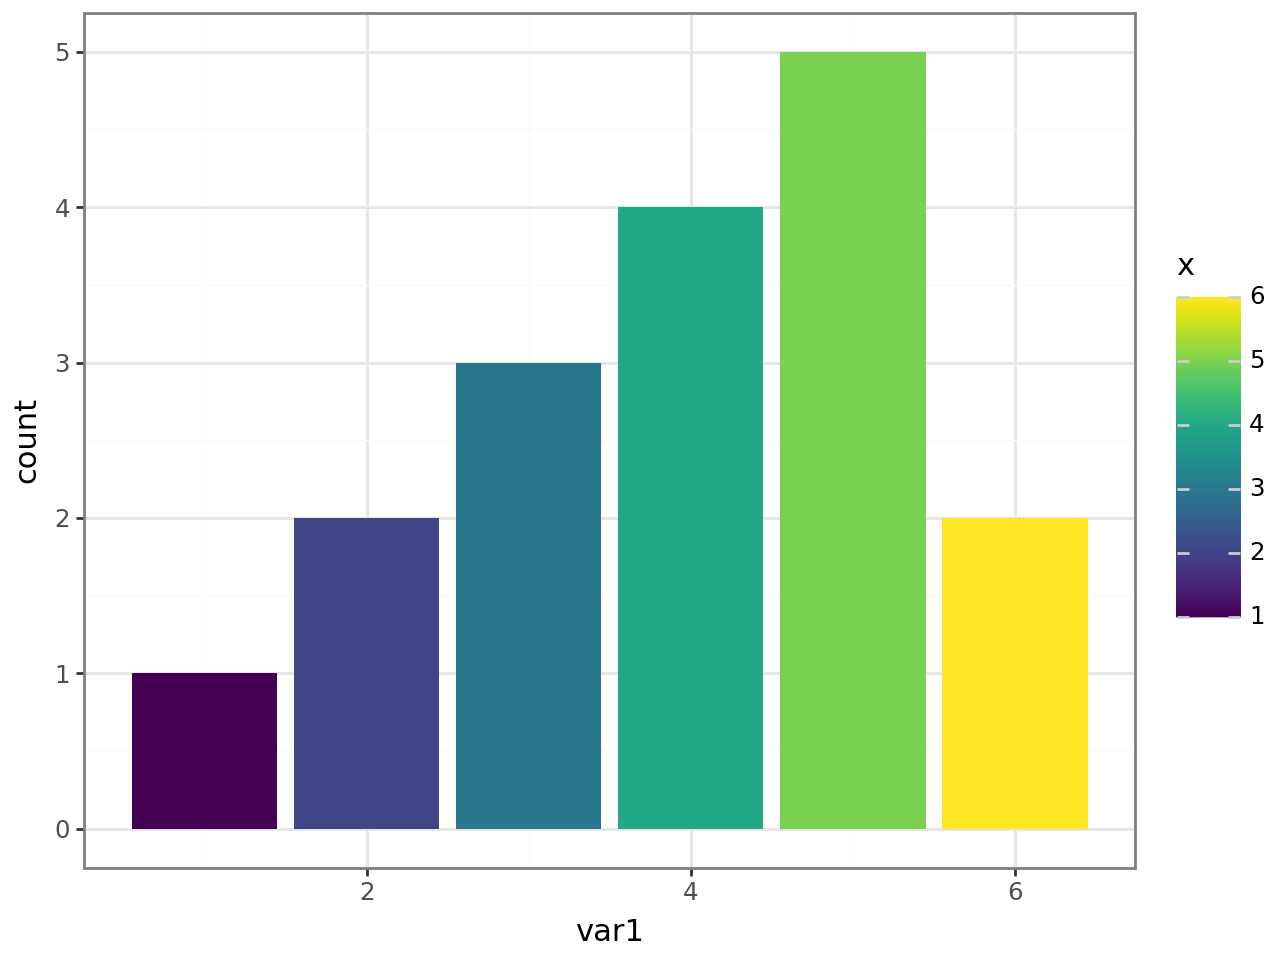

In [17]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count"),
            fill=p9.after_stat("x"),
        ),
    )
    + p9.theme_bw()
)
plot

We can use a different pseudo-variable for the fill: say, the count of each value: this color-codes the bars by height


The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting in a formulae that plotnine will evaluate. We try to set the fill according to one of the after-process pseudo-variable names  (Works!)
- set theme to black & white

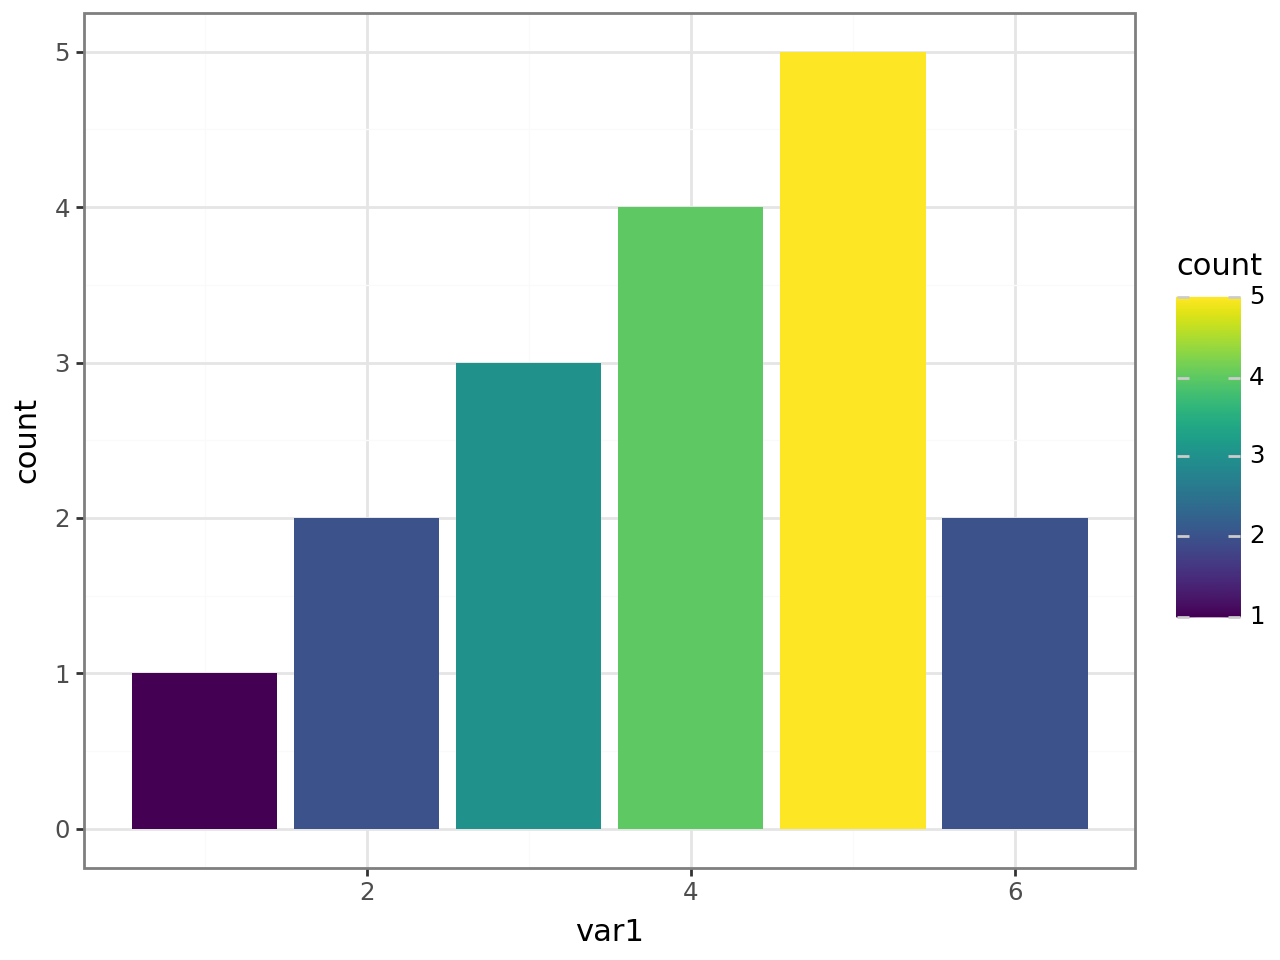

In [18]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count"),
            fill=p9.after_stat("count"),
        ),
    )
    + p9.theme_bw()
)
plot

### Multiple __stat__ calls

In the example below, we construct a plot with two layers: one holding vertical bars, one holding text annotations.
We use __geom_bar__ and __geom_text__.  In the call to __geom_text__ we specify that we want to call __stat_count__ for the statistical processing (overriding the default).
This means we can use the pseudo_variable "prop" (normalized counts) to set the label to be shown at the top of the bar (y __aes__ parameter set to the count, same as the bar)


The steps  are:
- create an empty plot, specifying the source dataframe
- create a bar graph (which calls a counting statistical process) and use the results from the counting in a formulae that plotnine will evaluate. We try to set the fill according to one of the after-process variable names 
- create a layer with text positioned at top of bars (same y value), with text label content derived from an after-process variable ("prop" = proportion), of the counting statistical process
- set theme to black & white

Note we have a number of different namespaces here:  the __stat__ in the __geom_text__ call is named "count", and this __stat__ creates a pseudo-variable "count": two completely different concepts, same name!

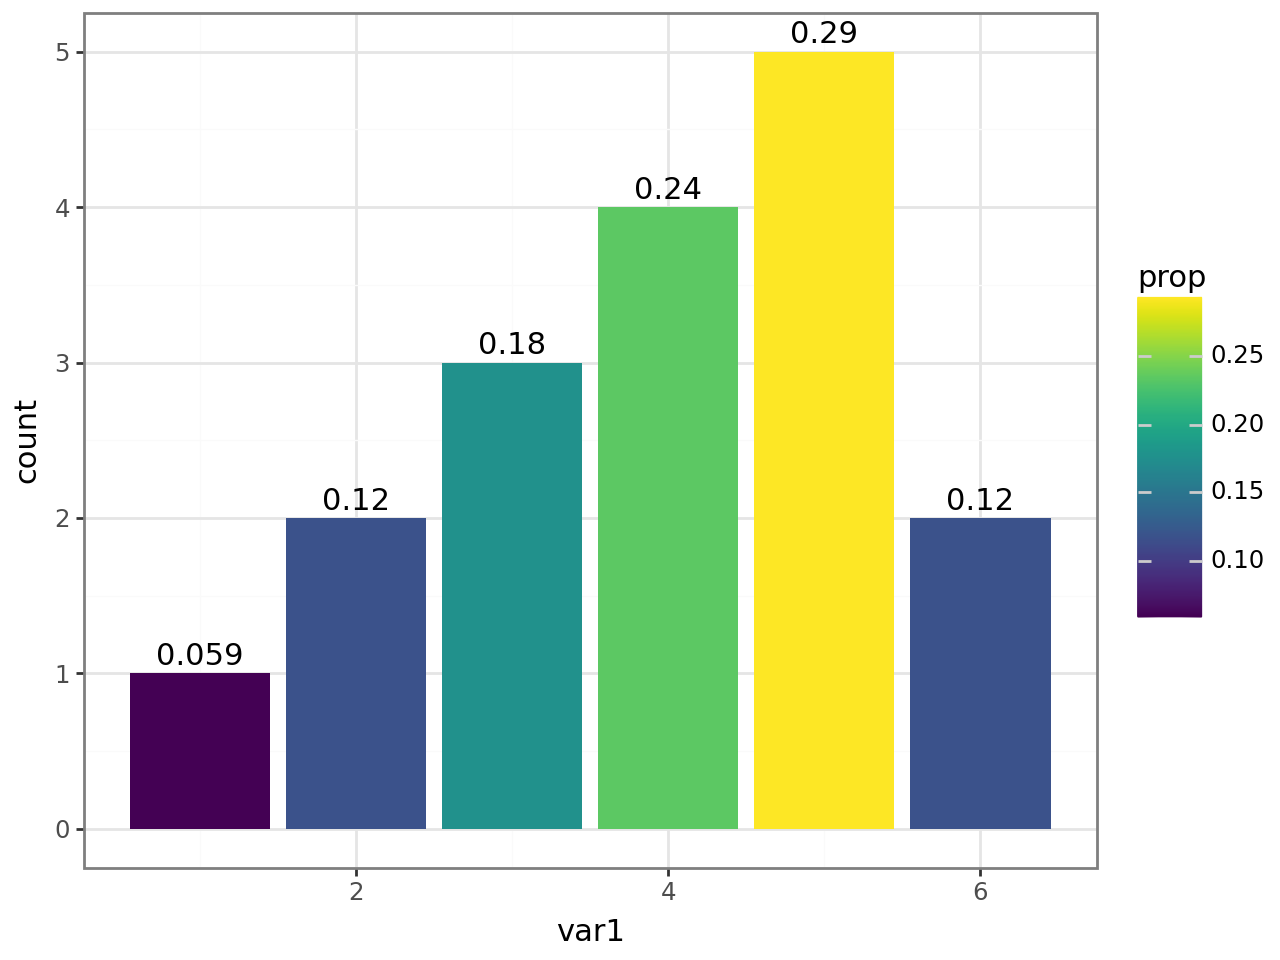

In [19]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_bar(
        mapping=p9.aes(
            x="var1",
            y=p9.after_stat("count"),
            fill=p9.after_stat("prop"),
        ),
    )
    # need outer stat=  so p9.aes(... after_stat..) works
    + p9.geom_text(
        mapping=p9.aes(x="var1", y=p9.after_stat("count"), label=p9.after_stat("prop")),
        stat="count",
        format_string="{:4.2}\n",
    )
    + p9.theme_bw()
)
plot

----------------------------
## More __stat__ examples

### __stat_hull__

Generate some random 2D points.  These points will be shown behind the output of the __stat...__ calls.

In [20]:
x = np.random.normal(0, 1, size)
y = np.random.normal(0, 2, size)


df = pd.DataFrame({"x": x, "y": y})

Find the convex hull os the points (by default, __stat_hull__ uses __geom_line__ to visualize the processing


The steps  are:
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for the convex hull process (that will draw a path)
- set theme to black & white

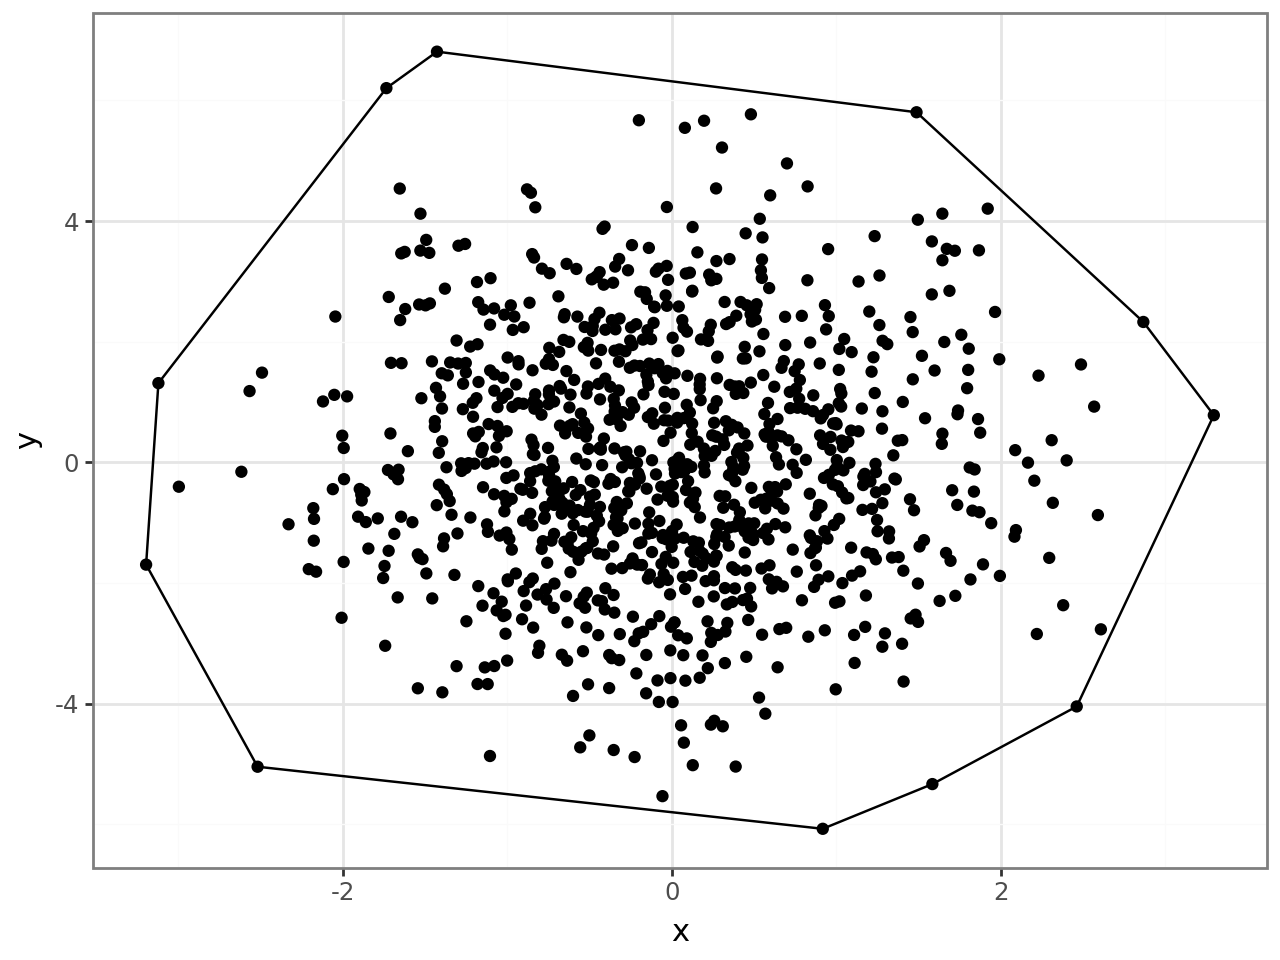

In [21]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(mapping=p9.aes(x="x", y="y"))
    + p9.stat_hull(
        mapping=p9.aes(x="x", y="y"),
    )
    + p9.theme_bw()
)
plot

--------------------
### __stat_ellipse__

Draw ellipses that enclose 50% (red) and 90% (blue) of the points

The steps  are:
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for the ellipse process (that will draw a path in blue)
- call for the ellipse process (that will draw a path in red)
- set theme to black & white

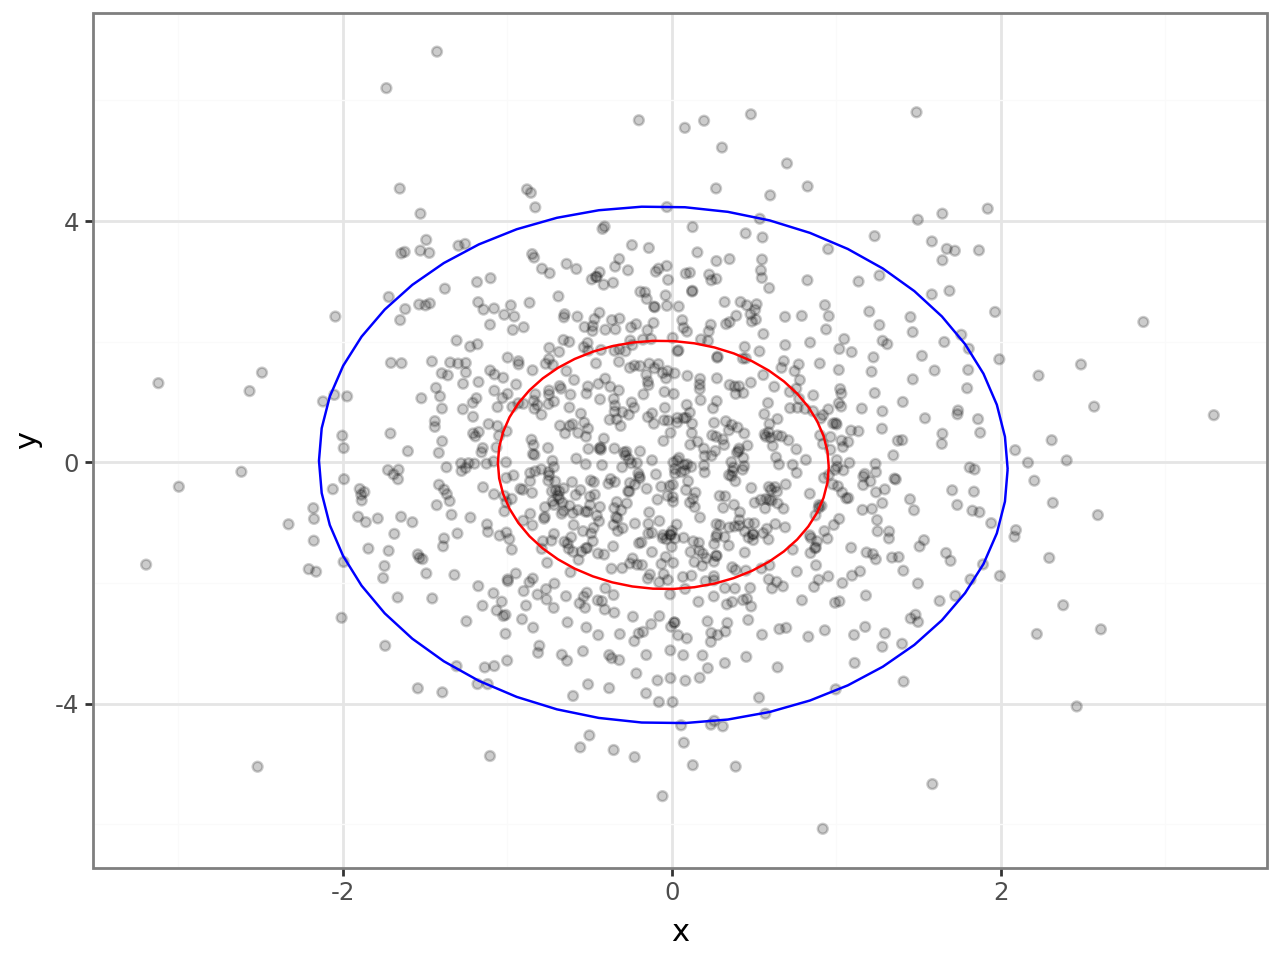

In [22]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.stat_ellipse(
        mapping=p9.aes(x="x", y="y"),
        color="blue",
    )
    + p9.stat_ellipse(
        mapping=p9.aes(x="x", y="y"),
        color="red",
        level=0.5,
    )
    + p9.theme_bw()
)
plot

------------------------

### __stat_function__

Computes and display as a line any function of a variable in the data environment.  Here we show a cubic y=x^3.

In [23]:
def cube(x):
    return x * x * x


# end sq

The steps  are:
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for the function calculation process, that will draw a line in blue
- set the y axis limits
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\layer.py:372: PlotnineWarning: geom_point : Removed 14 rows containing missing values.
C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\geoms\geom_path.py:100: PlotnineWarning: geom_path: Removed 48 rows containing missing values.


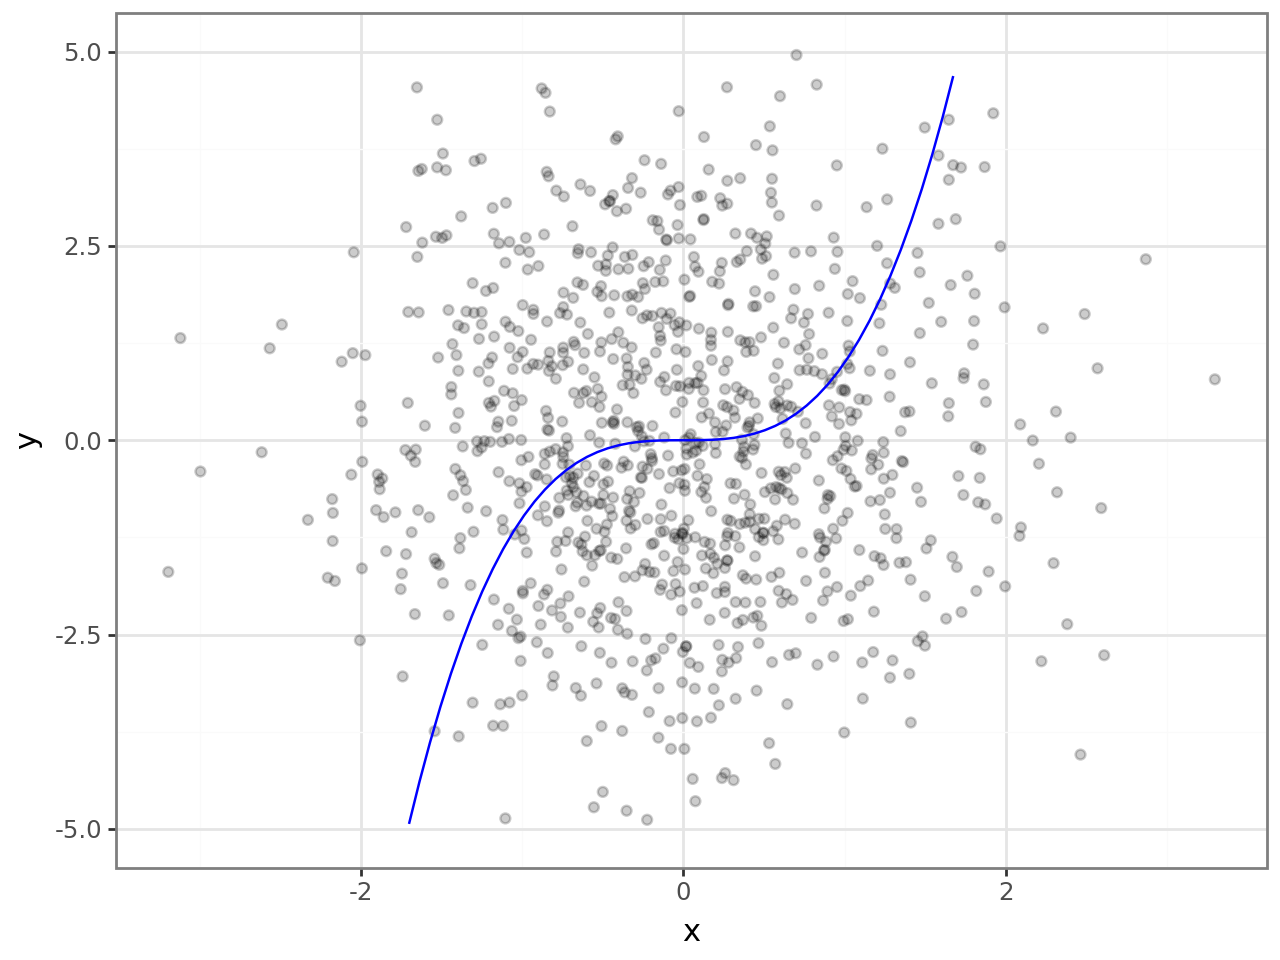

In [24]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.stat_function(
        mapping=p9.aes(
            x="x",
        ),
        fun=cube,
        color="blue",
    )
    + p9.ylim((-5, 5))
    + p9.theme_bw()
)
plot

--------------------

### __stat_density_2d__

Draws 2D density contours

The steps  are:
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for the 2D density process, that will draw contours in red
- set theme to black & white

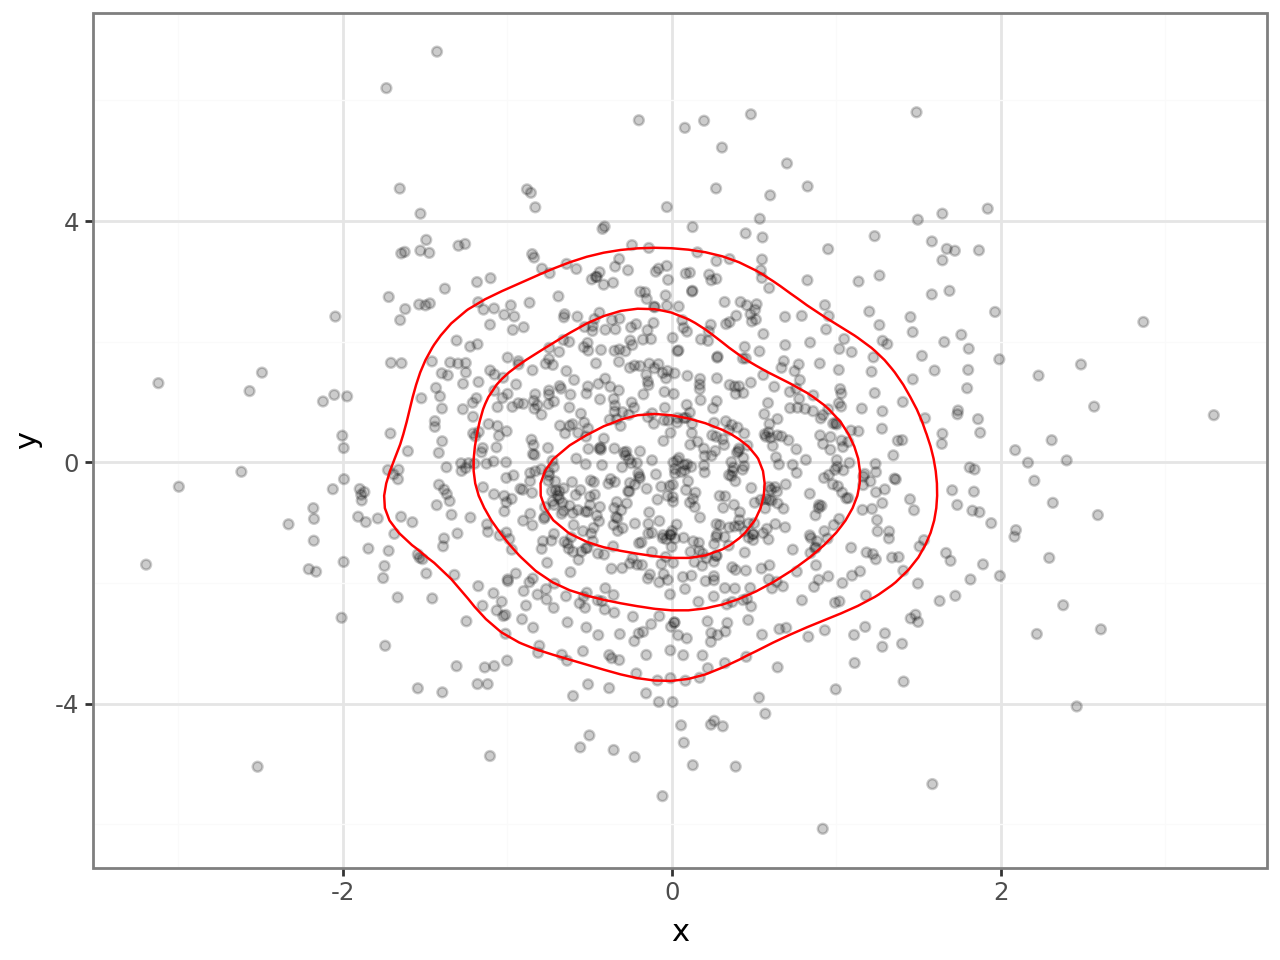

In [25]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.stat_density_2d(
        mapping=p9.aes(x="x", y="y"),
        color="red",
    )
    + p9.theme_bw()
)
plot

Draw more contours

The steps  are:
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for the 2D density process, that will draw multiple contours in red
- set theme to black & white

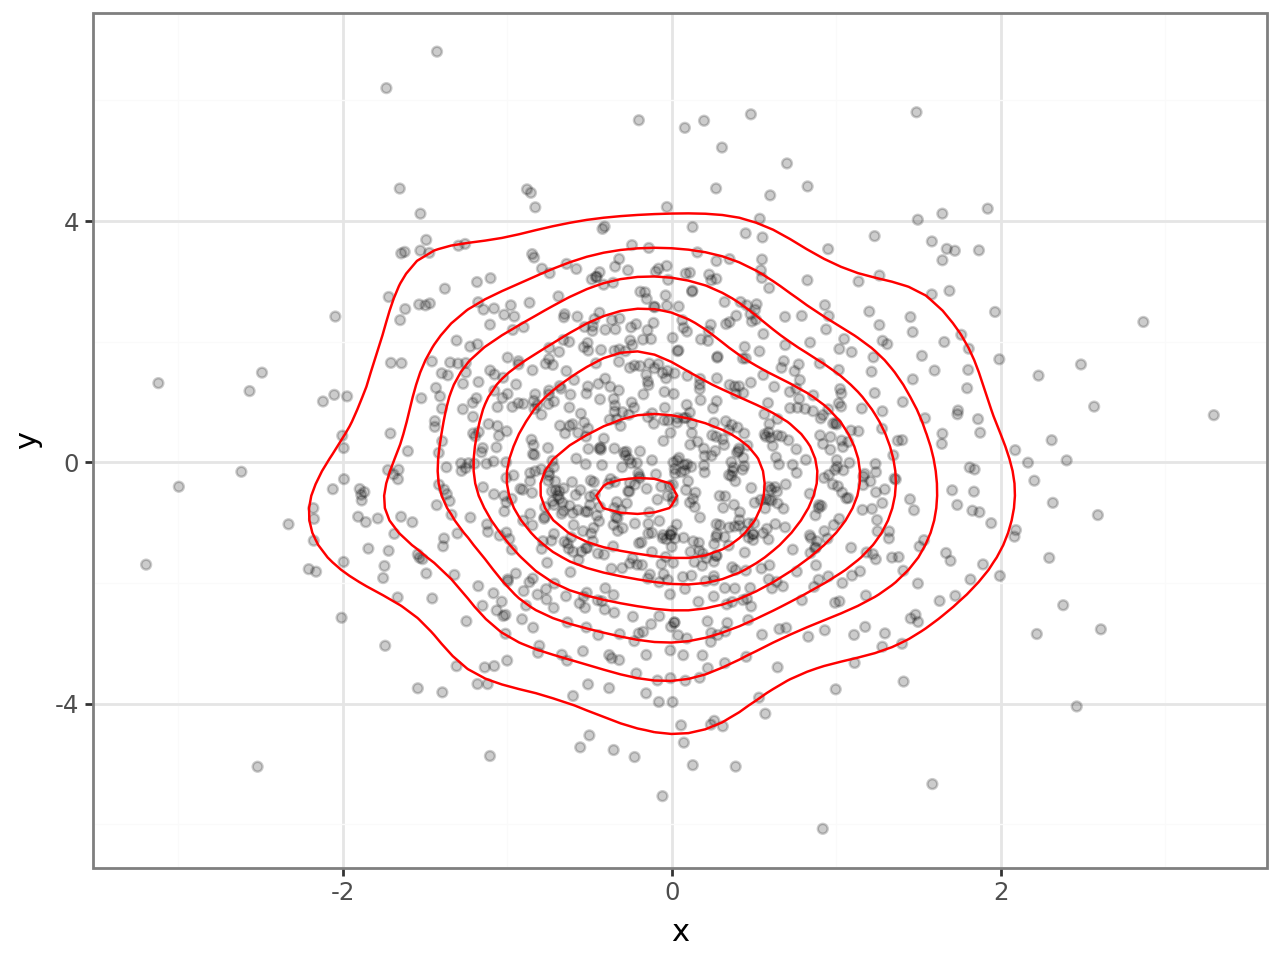

In [26]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.geom_density_2d(
        mapping=p9.aes(x="x", y="y"),
        color="red",
        levels=8,
    )
    + p9.theme_bw()
)
plot

-----------------------

### __stat_qq__ 

 A Q–Q plot (quantile–quantile plot):
 
     is a probability plot, a graphical method for comparing two probability distributions by plotting their quantiles against each other.

It is typically used to test for normality of a random variable.  In the graph below, the Q–Q plot compares a sample of data on the vertical axis to a statistical population on the horizontal axis. The points follow a strongly linear pattern, suggesting that the data are  distributed as a standard normal (X ~ N(0,1)).  The zero offset between the line and the points suggests that the mean of the data is  0.  Which we knew, as this is how we created the data.

The steps  are:
- create an empty plot, specifying the source dataframe
- generate a QQ plot using random data from the dataframe
- call the qq_line process, that will plot a line for the normal distribution on the plot
- set theme to black & white

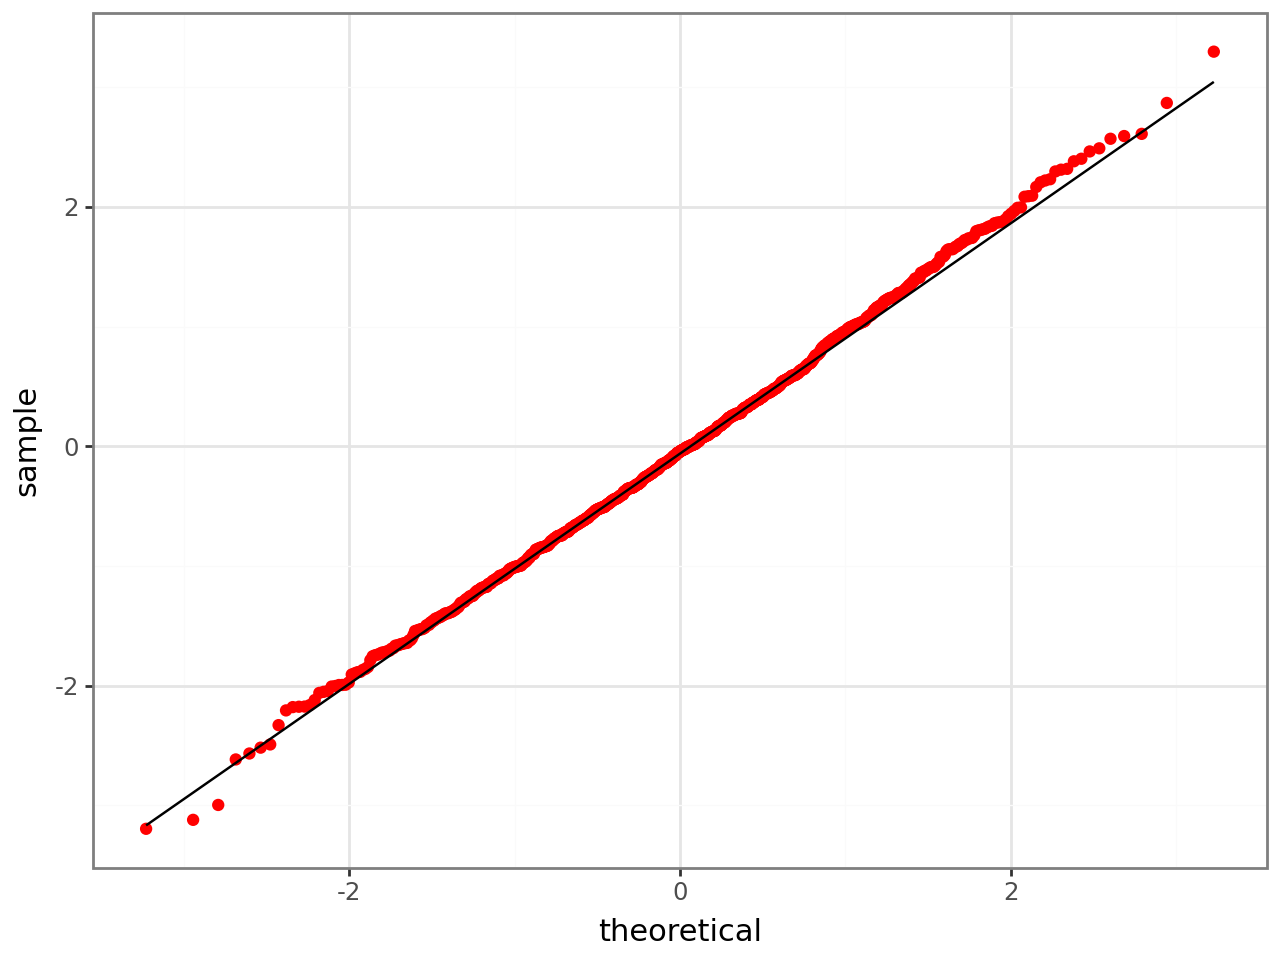

In [27]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_qq(
        mapping=p9.aes(sample="x"),
        color="red",
    )
    + p9.stat_qq_line(mapping=p9.aes(sample="x"))
    + p9.theme_bw()
)
plot

--------------------

### ___stat_quantile__, __geom_quantile__

Quantile regression:

    is a type of regression analysis used in statistics and econometrics. Whereas the method of least squares estimates the conditional mean of the response variable across values of the predictor variables, quantile regression estimates the conditional median (or other quantiles) of the response variable

We generate correlated but noisy data, and construct a plot showing:

- the data points
- the estimate 25% 50% and 75% quantiles

The steps  are:
- generate a dataframe with noisy data
- create an empty plot, specifying the source dataframe
- create a layer holding points
- generate the quantile regression lines
- set theme to black & white

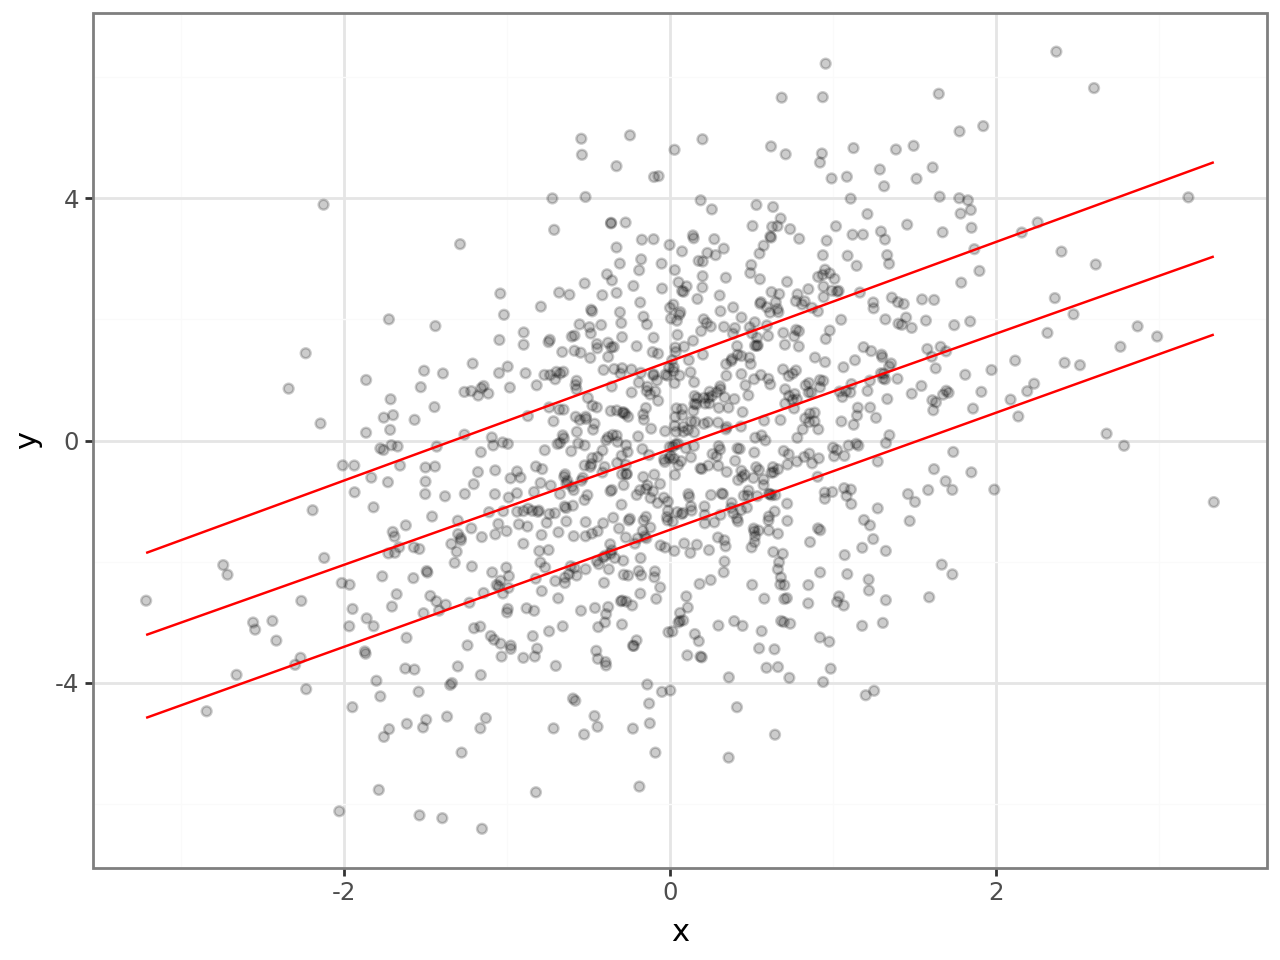

In [28]:
x = np.random.normal(0, 1, size)
y = x + np.random.normal(0, 2, size)


df = pd.DataFrame({"x": x, "y": y})


plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.geom_quantile(
        mapping=p9.aes(x="x", y="y"),
        color="red",
    )
    + p9.theme_bw()
)
plot

In this example, we use __stat_quantile__, and use a pseudo-variable to color-code the quantile lines.  We use the pseudo-function "factor" to indicate we have only discrete values, and not a continuous gradient

The steps  are:
- generate a dataframe with noisy data
- create an empty plot, specifying the source dataframe
- create a layer holding points
- call for a statistical process that will draw quantile regression lines, color coding for quantile value
- set theme to black & white

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.


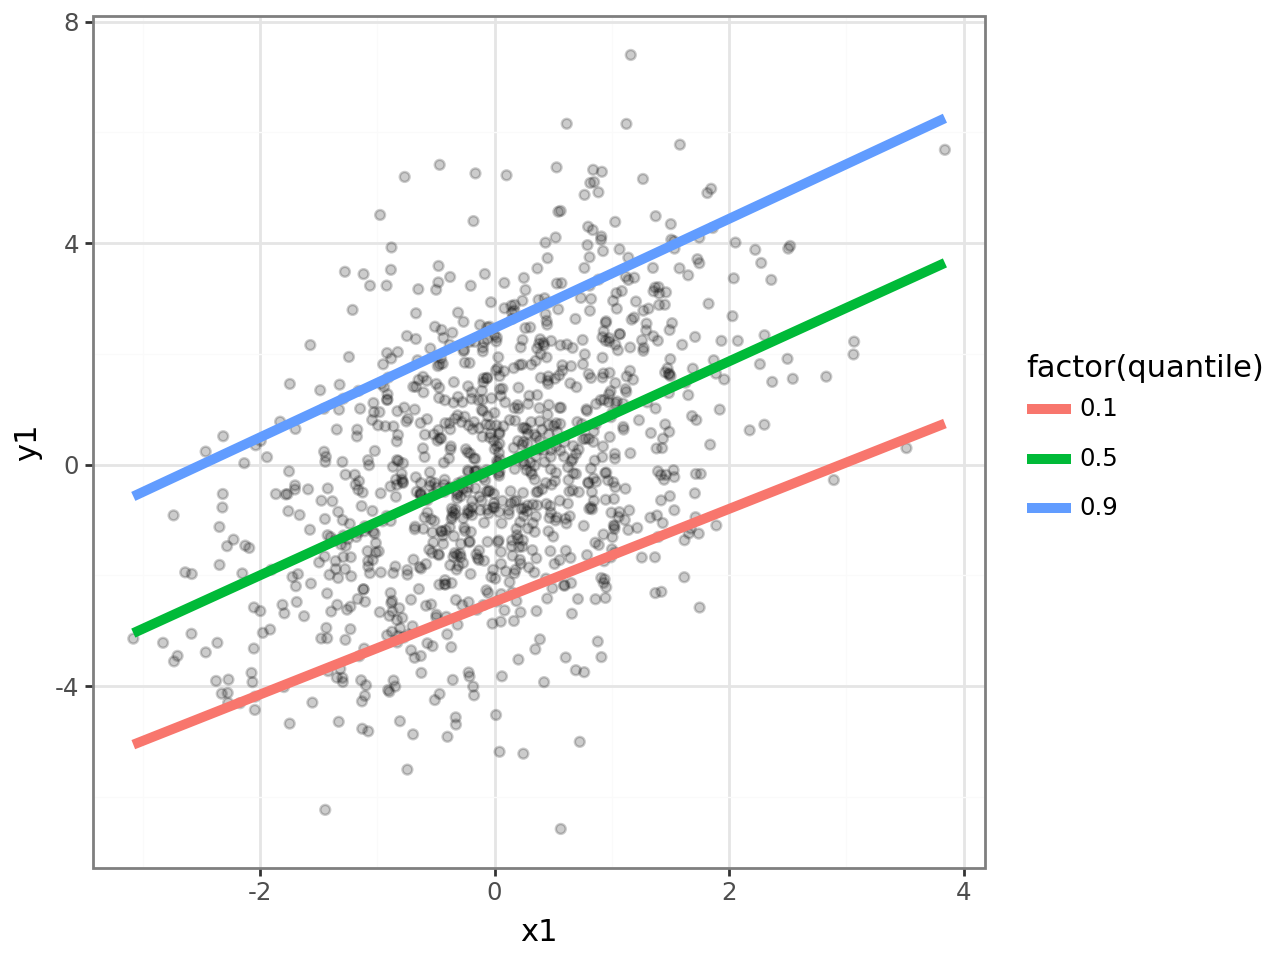

In [29]:
x = np.random.normal(0, 1, size)
y = x + np.random.normal(0, 2, size)


df = pd.DataFrame({"x1": x, "y1": y})

plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.stat_quantile(
        mapping=p9.aes(x="x1", y="y1", color=p9.after_stat("factor(quantile)")),
        quantiles=(0.1, 0.5, 0.9),
        size=2,
    )
    + p9.theme_bw()
)
plot

---------------------

## Density visualization

This section will provide examples of visualizing density in one and two dimensions

### __geom_rug__

Rug plots are drawn in one dimension by generating tick marks for each data point, on the x and / or y axis.

The steps  are:

- create an empty plot, specifying the source dataframe
- create a layer holding points, increasing the transparency (alpha) so as to not draw the eye
- generate the rug plot on x and y axis, showing density of points when projected on each axis
- set theme to black & white

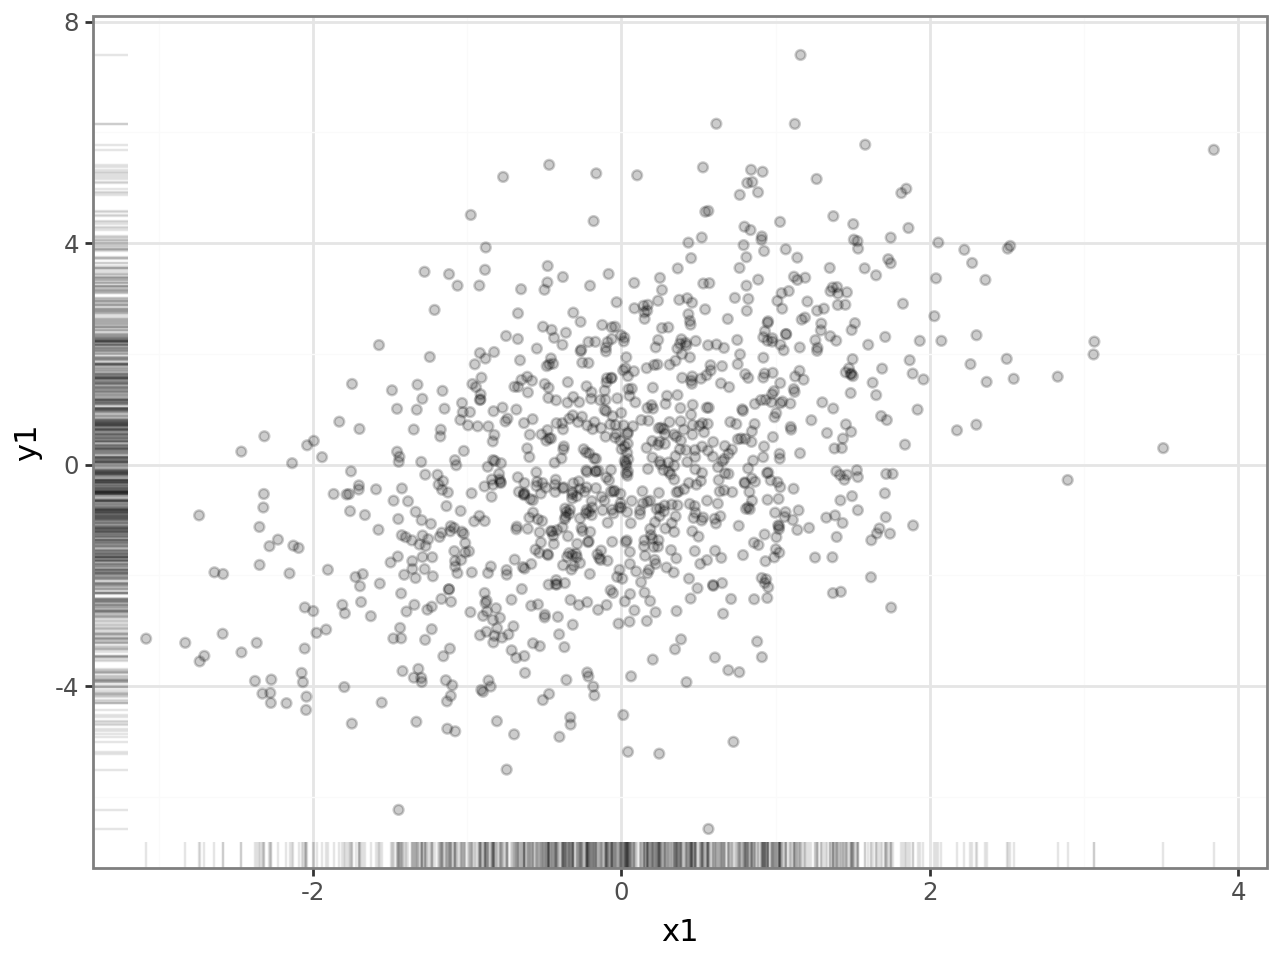

In [30]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.geom_rug(
        mapping=p9.aes(
            x="x1",
            y="y1",
        ),
        alpha=0.1,
    )
    + p9.theme_bw()
)
plot

--------------------

### Y axis density graphs

There are two ways to visualize the density of points in the y-axis.  These are:

- stat_ydensity
- stat_density

#### stat_ydensity

__stat_ydensity__ seems to have been created largely as a helper function for violin plots, but it can be used as a general purpose function.

The statistical process takes a set of values via the y parameter (in our case actually y-axis coordinates) and generates a pseudo-variable "violinwidth" that gives the estimated density at each input value.  By default, this stat draws a violin plot, but we can override this to just draw a path.  Note that the y parameter is defined for the __stat__ and __geom__ calls, and holds the same values (y-axis coordinates values)

The steps  are:

- create an empty plot, specifying the source dataframe
- create a layer holding points, made transparent
- call the y axis density statistical process, specifying the visualization is via a path (continuous line), with path x values being density values (translated  to the left), path y values being data y values 
- draw a vertical line as a y=0 axis for the density curve
- set theme to black & white

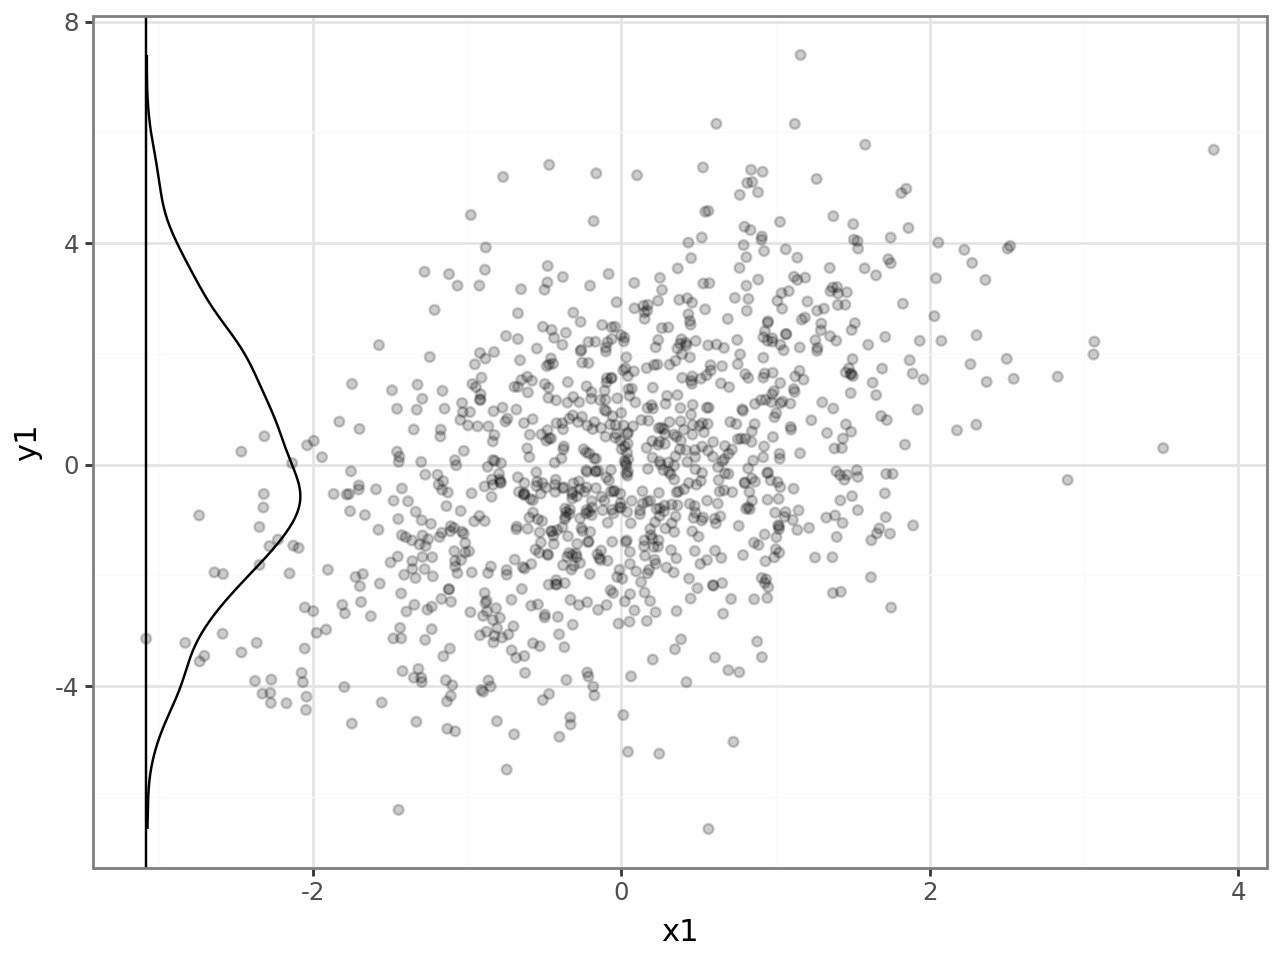

In [31]:
xmin = abs(min(df["x1"]))

plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.stat_ydensity(
        mapping=p9.aes(x=p9.after_stat("violinwidth-xmin"), y="y1"), geom="path"
    )
    + p9.geom_vline(mapping=p9.aes(xintercept=-xmin))
    + p9.theme_bw()
)
plot

#### stat_density

This example is a little convoluted, but illustrates the use of the __stage__ function. 

The __stage__ function allows us to handle the case where the __stat_ ...__ and the subsequent __geom_...__ have the same parameter defined (in this case __x=...__),  but require a completely different set of values.

To illustrate the __stat_density__ needs a set of values to use to estimate density, assigned via the x parameter.  We want density along the y axis, so we say we want to start by assigning x the values of the pseudo-variable "y1" (being a column in our source dataframe). Then, after the staistical processing, and when we start drawing the path, we want x to be the estimated density (from the after-process pseudo-variable "scaled".

Thus we have (-x_min just translates the graph to the left):

    x=p9.stage(start="y1", after_stat="scaled-x_min"),

For the parameter y (which stat_density doesn't use, but geom_path requires), we start by assigning y to 0.  Then after the processing, we need the y-axis values, but the statistical process trashed our start environment (pseudo-variables mapping to dataframe column names): thankfully, the statistical process stores the input set of values (used to compute density) under the pseudo-variable "x".  Se we can tell __geom_path__ to use this "x" pseudo-variable to get y-axis values to draw a line.

Thus we have:

    y=p9.stage(start=0, after_stat="x"),

The steps are:

- create an empty plot, specifying the source dataframe
- create a layer holding points, made transparent
- call the general density statistical process, specifying the visualization is via a path (continuous line), with path x values being density values (translated to the left), path y values being data y values ((translated to the left)
- draw a vertical line as a y=0 axis for the density curve
- set theme to black & white


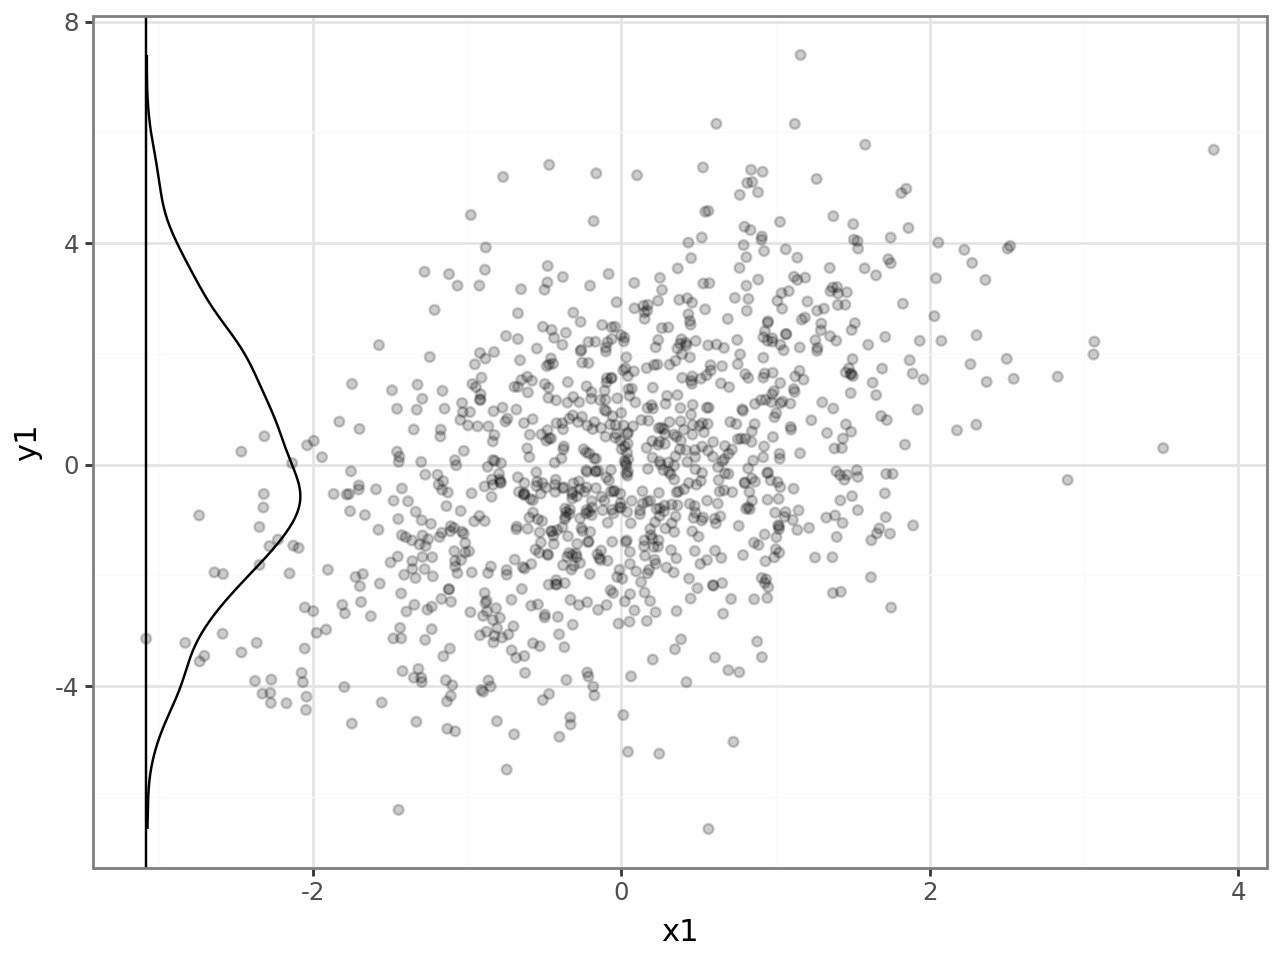

In [32]:
x_min = abs(min(x))

df = pd.DataFrame({"x1": x, "y1": y})

plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.stat_density(
        mapping=p9.aes(
            x=p9.stage(start="y1", after_stat="scaled-x_min"),
            y=p9.stage(start=0, after_stat="x"),
        ),
        geom="path",
    )
    + p9.geom_vline(mapping=p9.aes(xintercept=-x_min))
    + p9.theme_bw()
)
plot

#### X Axis density curve

After all the complexity of drawing a density curve on the y-axis, the x-axis is less complex.  We can use the __geom_density__ call, the only complication being to scale the density, and translate away from the cluster of points

The steps  are:

- create an empty plot, specifying the source dataframe
- create a layer holding points
- generate a density curve, x values being x data values, y values being scaled density values (translated  down)
- draw a horizontal line as a y=0 axis for the density curve
- set theme to black & white

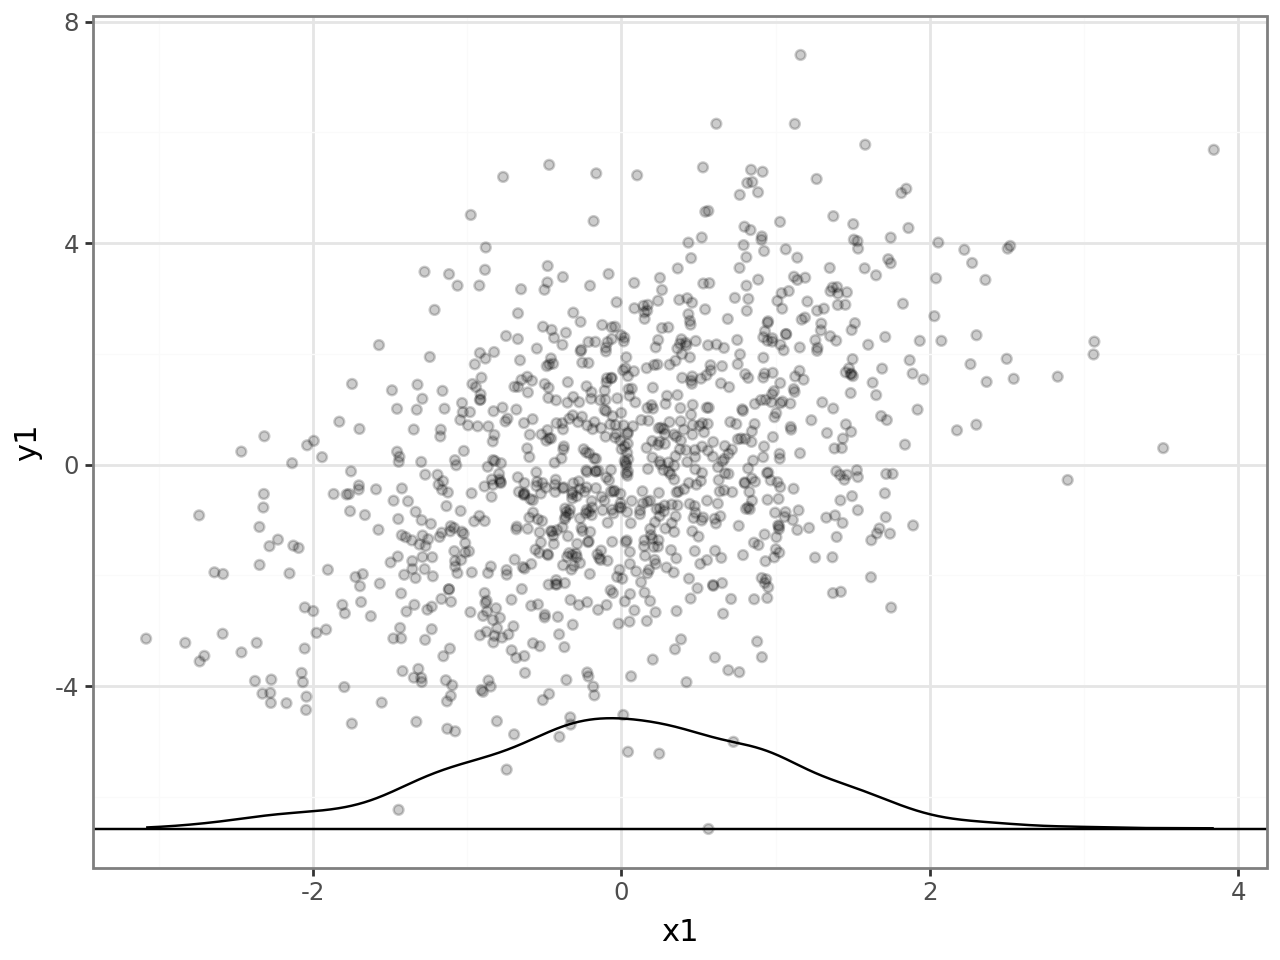

In [33]:
y_min = abs(min(y))
scaling = 2

plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.geom_density(mapping=p9.aes(x="x1", y=p9.after_stat("scaled*scaling-y_min")))
    + p9.geom_hline(mapping=p9.aes(yintercept=-y_min))
    + p9.theme_bw()
)
plot

#### Multi-examples

Here we demonstrate on the same plot:

- rug plots on the x axis
- rug plots on the y axis
- y-axis density plot
- x-axis density plot
- 2D density contours
- 2D density ellipses

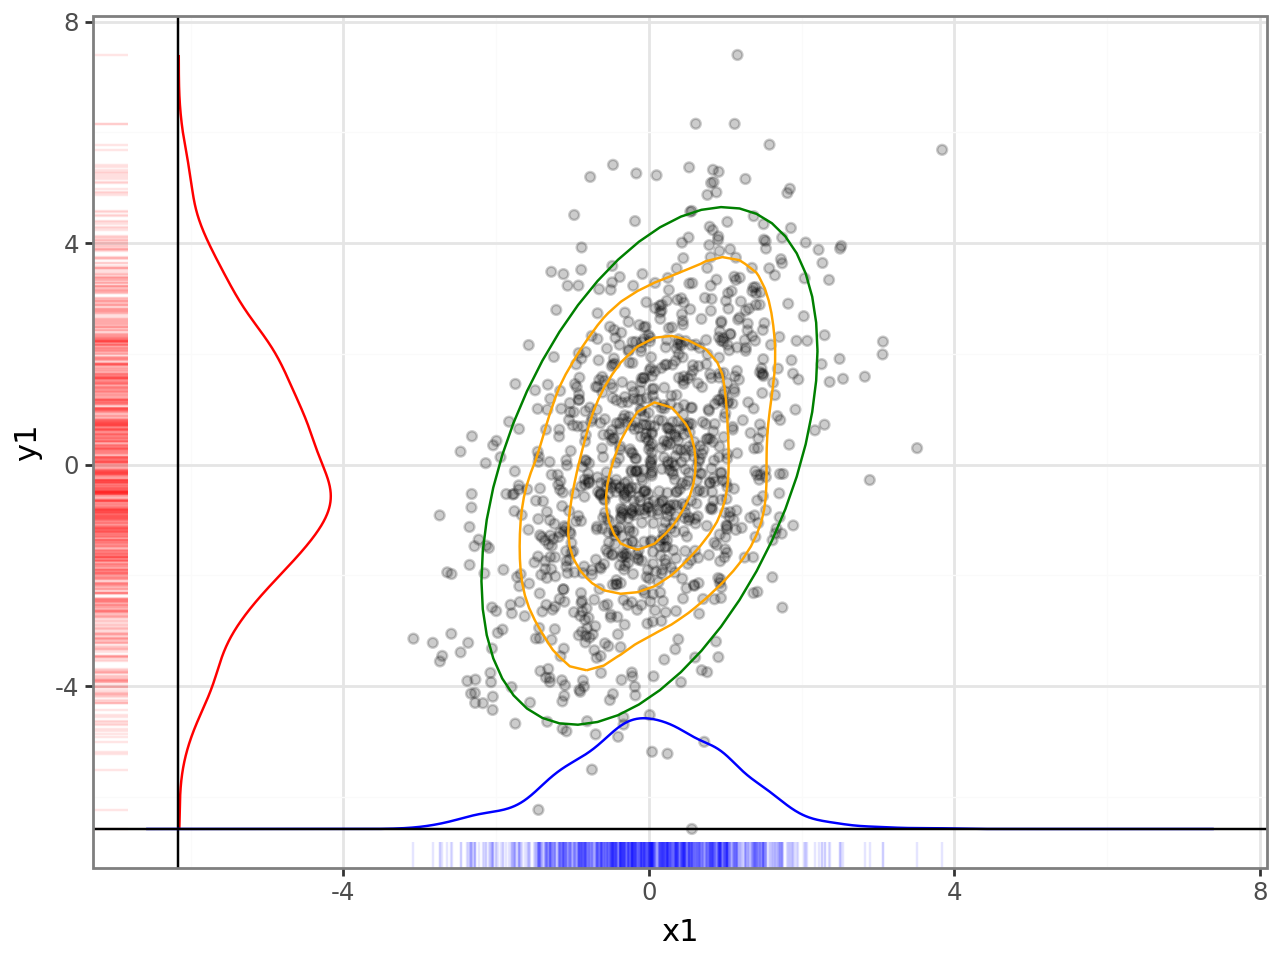

In [34]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x1", y="y1"),
        alpha=0.2,
    )
    + p9.geom_rug(
        mapping=p9.aes(
            x="x1",
            # y="y1",
        ),
        alpha=0.1,
        color="blue",
    )
    + p9.geom_rug(
        mapping=p9.aes(
            # x="x1",
            y="y1",
        ),
        alpha=0.1,
        color="red",
    )
    + p9.stat_density(
        mapping=p9.aes(
            x=p9.stage(start="y1", after_stat="scaled*scaling-xmin*2"),
            y=p9.stage(start=0, after_stat="x"),
        ),
        geom="path",
        color="red",
    )
    + p9.geom_vline(mapping=p9.aes(xintercept=-x_min * 2))
    + p9.geom_density(
        mapping=p9.aes(x="x1", y=p9.after_stat("scaled*scaling-y_min")),
        color="blue",
    )
    + p9.geom_hline(mapping=p9.aes(yintercept=-y_min))
    + p9.stat_density_2d(
        mapping=p9.aes(x="x", y="y"),
        color="orange",
    )
    + p9.stat_ellipse(
        mapping=p9.aes(x="x1", y="y1"),
        color="green",
    )
    + p9.theme_bw()
)
plot

------------------

#### 2D binning

In this example we generate random uniform sample (0-1) for the x- and y-axis, and pour these into a dataframe.  We use __geom_bin_2d__ to produce a heatmap style visualization of the density of points



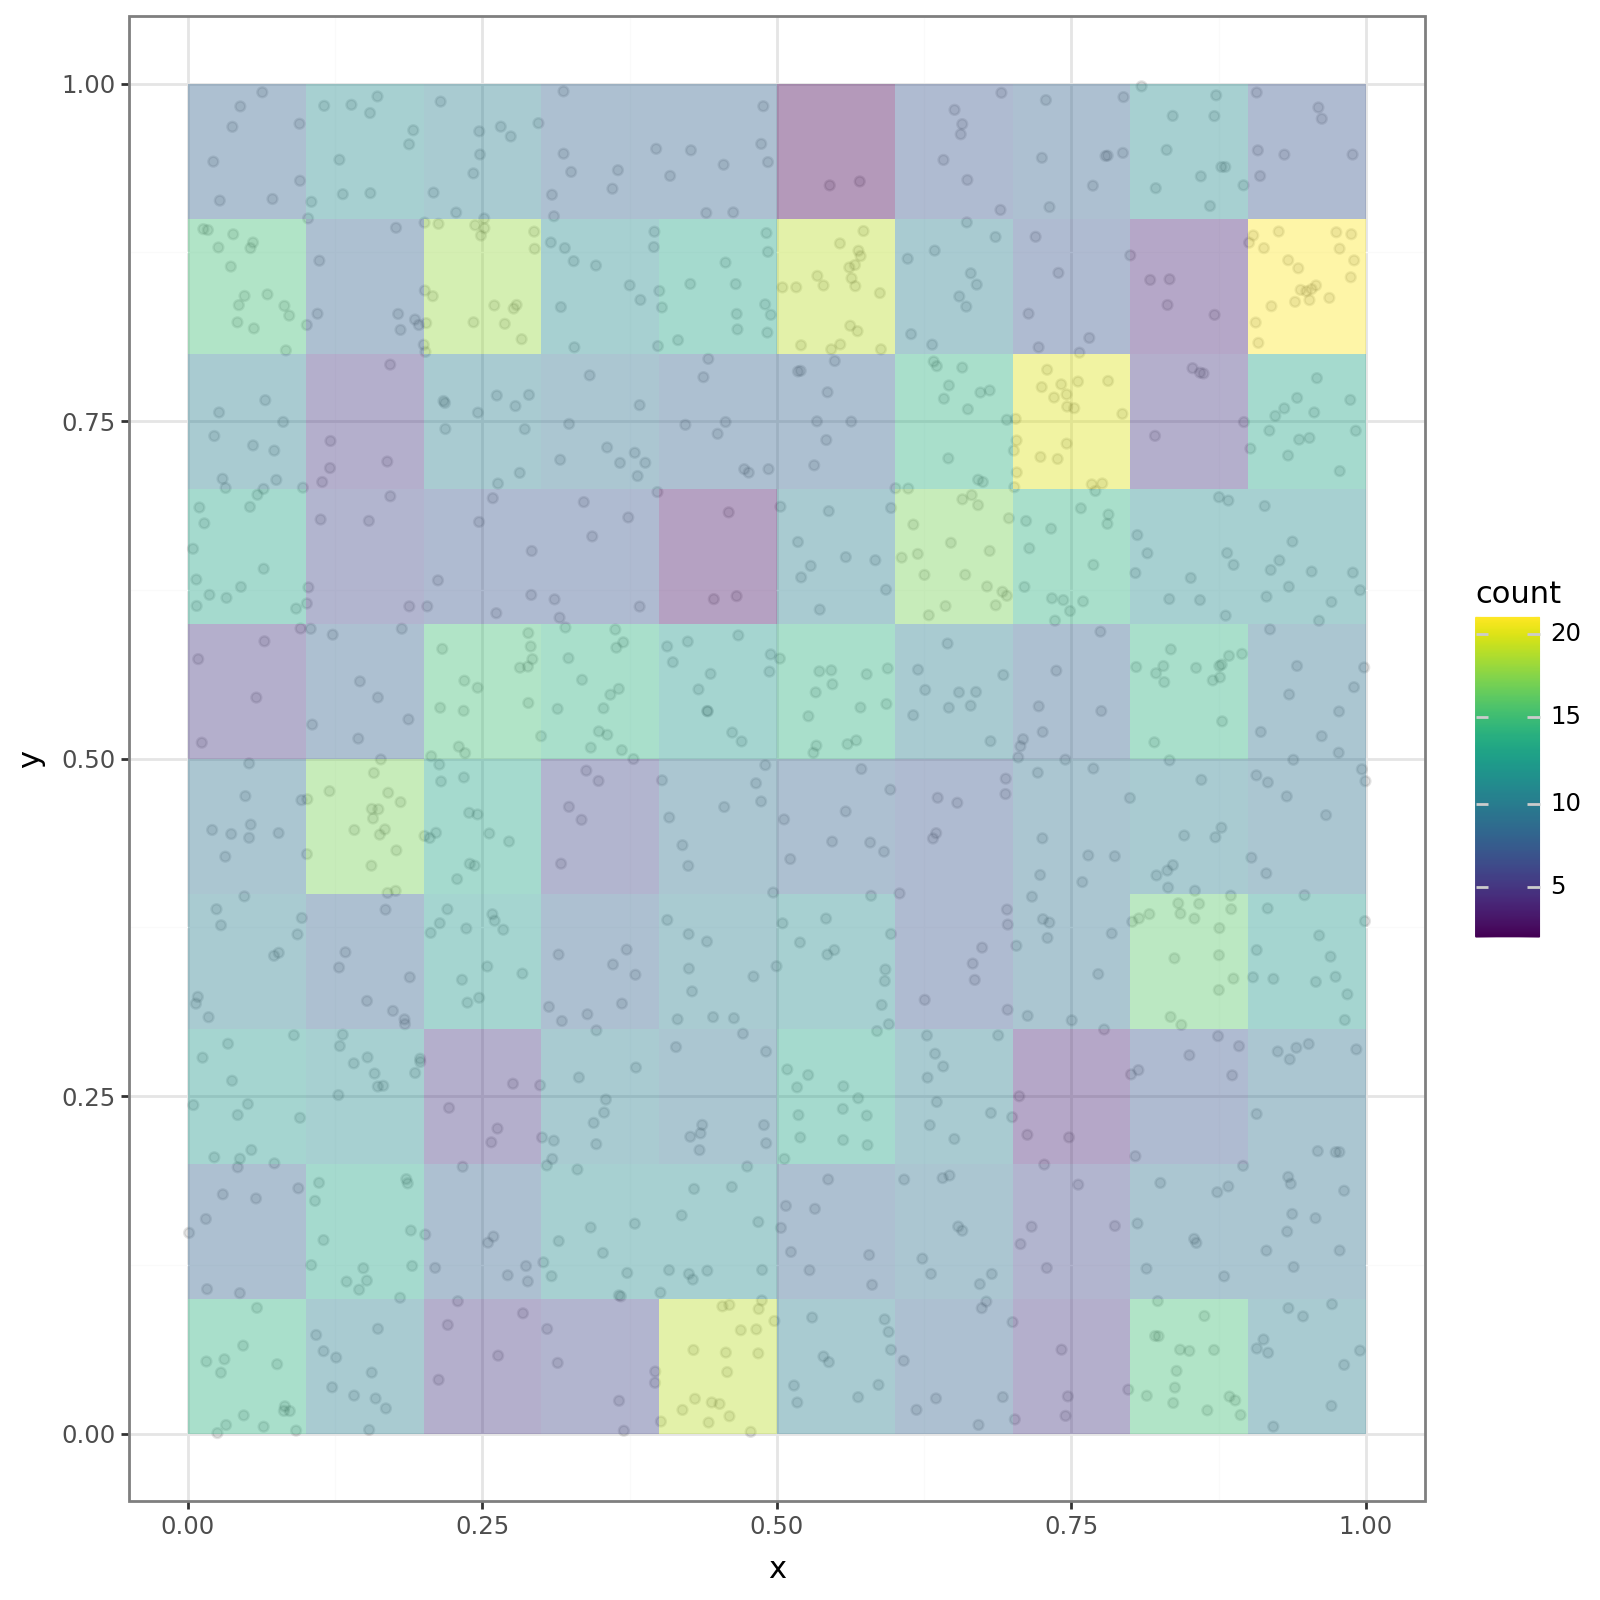

In [35]:
size = 100

x = np.random.rand(1000)
y = np.random.rand(1000)


df = pd.DataFrame({"x": x, "y": y})

plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.1,
    )
    + p9.geom_bin_2d(
        mapping=p9.aes(
            x="x",
            y="y",
        ),
        binwidth=0.1,
        alpha=0.4,
    )
    + p9.theme_bw()
    + p9.theme(
        figure_size=(8, 8),
    )
)
plot

Now suppose we want to show the count in each 2D bin, as a text annotation

The __stat_bin_2d__ creates the following pseudo-variables:

    Options for computed aesthetics

    - "xmin"    # x lower bound for the bin
    - "xmax"    # x upper bound for the bin
    - "ymin"    # y lower bound for the bin
    - "ymax"    # y upper bound for the bin
    - "count"   # number of points in bin
    - "density" # density of points in bin, scaled to integrate to 1

We perform the initial steps as before:

- create and empty plot, specifying our data source
- call __geom_bin_2d__ to show a color-coded visualization of the density in each bin (100 in all - 10*10)

Then we call __stat_bin_2d__,  specifying we want __geom_text__ called after the 2D binning process.   Again, __stat_bin_2d__ and __geom_text__ have two variables "x"and "y", with different meanings in each context.

In the __stat_bin_2d__ context, "x" and "y" are the point coordinates (we count the number of points in each 2D bin).

In the __geom_text__ context, "x" and "y" are the coordinates of where a given text label is to appear.

So:

            x=p9.stage(
                start="x",
                after_stat="(xmin+xmax)/2",
            ),
says: for the __stat__ processing, set the parameter "x" to the dataframe column "x": in the __geom_text__ context, set the x parameter to the x-axis midpoint of each bin (as computed from pseudo-variables created by the __stat__ process)

Similarly:

            y=p9.stage(
                start="y",
                after_stat="(ymin+ymax)/2",
            ),

says the same above, except for the y-axis.

The label mapping parameter in:

            label=p9.after_stat("count"),

is not used by the __stat__ process, but is passed on to the __geom__ call.  It says: use the post-stat process pseudo-variable "count" to be mapped to the label in the __geom_text__ call.

There are a set of __geom__text__ settings declared in the __stat_bin_2d__ call that get passed on to  __geom_text__ :

        size=8,
        format_string="{:.0f}",
        color="black",
        path_effects=[pe.withStroke(linewidth=3, foreground="lightgray")],


The __patheffects__ module allows for backgrounds behind text to be easier to read on dark backgrounds

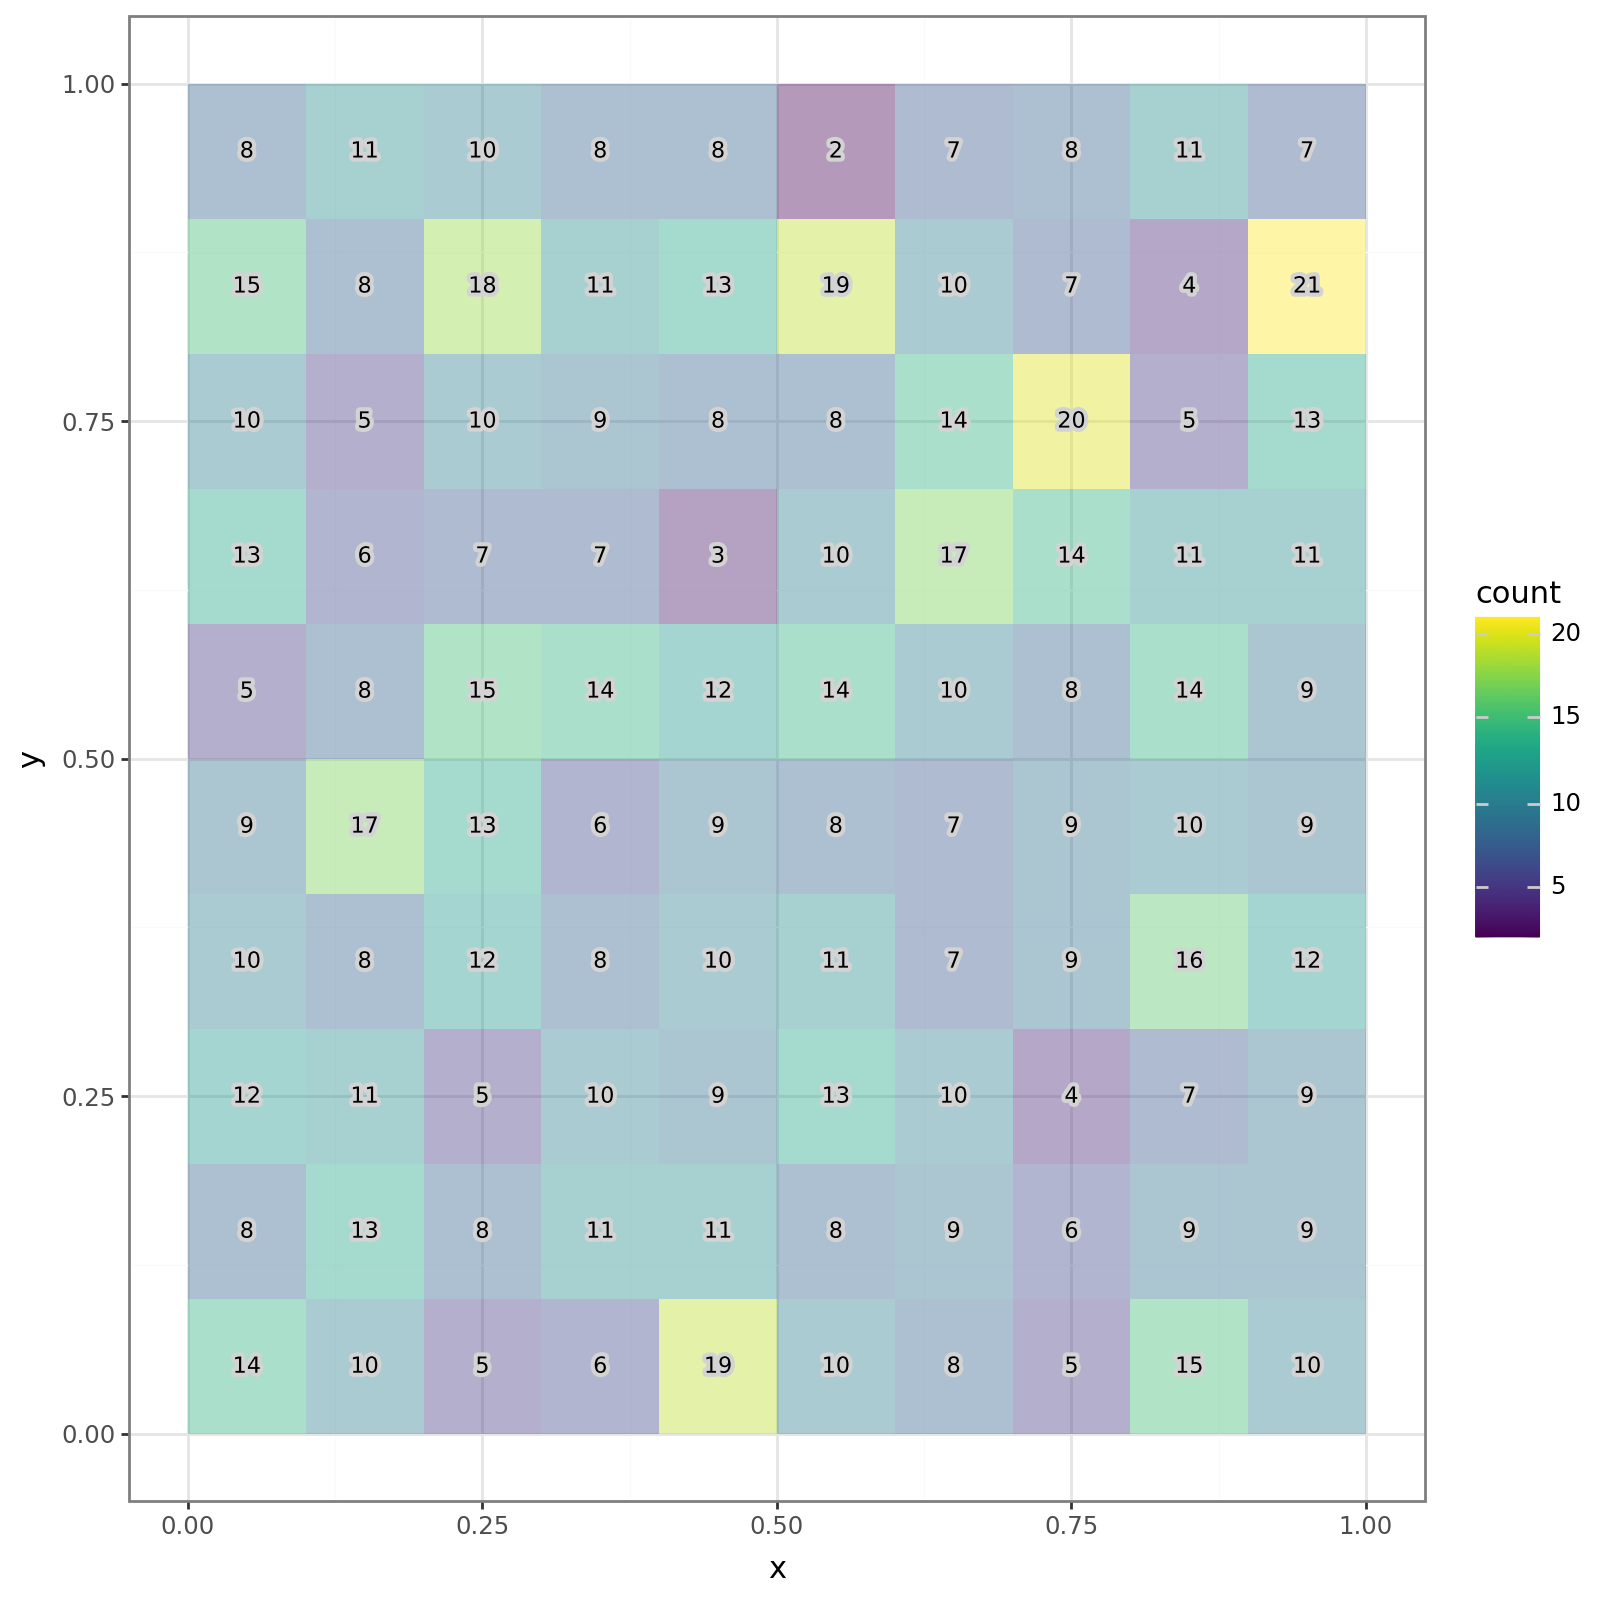

In [36]:
import matplotlib.patheffects as pe

plot = (
    p9.ggplot(data=df)
    + p9.geom_bin_2d(
        mapping=p9.aes(
            x="x",
            y="y",
        ),
        binwidth=0.1,
        alpha=0.4,
    )
    + p9.stat_bin_2d(
        mapping=p9.aes(
            x=p9.stage(
                start="x",
                after_stat="(xmin+xmax)/2",
            ),
            y=p9.stage(
                start="y",
                after_stat="(ymin+ymax)/2",
            ),
            label=p9.after_stat("count"),
        ),
        geom="text",
        binwidth=0.1,
        size=8,
        format_string="{:.0f}",
        color="black",
        path_effects=[pe.withStroke(linewidth=3, foreground="lightgray")],
    )
    + p9.theme_bw()
    + p9.theme(
        figure_size=(8, 8),
    )
)
plot

----------------------------------

### Use of helper functions

I was curious as the the distribution of the bin counts in the graphic above.  They should have a mean of 10 (10*10 = 100 bins, 1,000 points), and look like a Binomial distribution (  (0.01 +0.99)^1000 ).  The __stat_bin_2d__ process creates a pseudo-variable "count", that is an array holding the points inside each bin.  To plot the distribution, I would to get the unique values present in the array, and then count how often each value occurs. For example, if we have counts of (2,2,4,5,5,5), I want to generate the unique values array (2, 4, 5) and the value_counts (2, 1, 3): the value 2 appears twice,the value  4 appears only one time, the value 5 appears three times.

I create some helper functions.  It appears that plotnine expects to deal with Pandas Series objects

In [37]:
def unique(l):
    """
    unique: get the unique values from a Pandas Series, returned as a pandas Series

    Get the input Pandas Series values, turn them into a list, then into a set, then into a list, then into a Series

    list -> set -> list removes duplicates
    """
    return pd.Series(list(set(list(l.values))))


# end unique


def my_count_items(l):
    """
    my_count_items: get count of how often each unique value appears in a Pandas Series, returned as a pandas Series
    """

    return pd.Series([list(l.values).count(i) for i in unique(l)])


# end my_count_items

The steps are:

- create an empty plot, specifying the source of data (df dataframe)
- invoke  __stat_bin_2d__, specifying the use of  __geom_col__ for visualization.  Both __stat_bin_2d__ and __geom__col__ use the x and y mapping variables.  We use __p9.stage( ... )__ to specify that the starting statistical process uses the "x", and "y" columns from the dataframe.  After the statistical processing, we want the __geom_col__ to use the results of my functions operating on the "count" pseudo-variable (x now holds the unique values, y the frequency of occurance of each unique value)
- set the theme to black and white
- set the figure size
- set the explanatory labels on the plot

C:\Users\donrc\anaconda3\envs\fun_minim\Lib\site-packages\plotnine\layer.py:356: PlotnineWarning: position_stack : Removed 80 rows containing missing values.


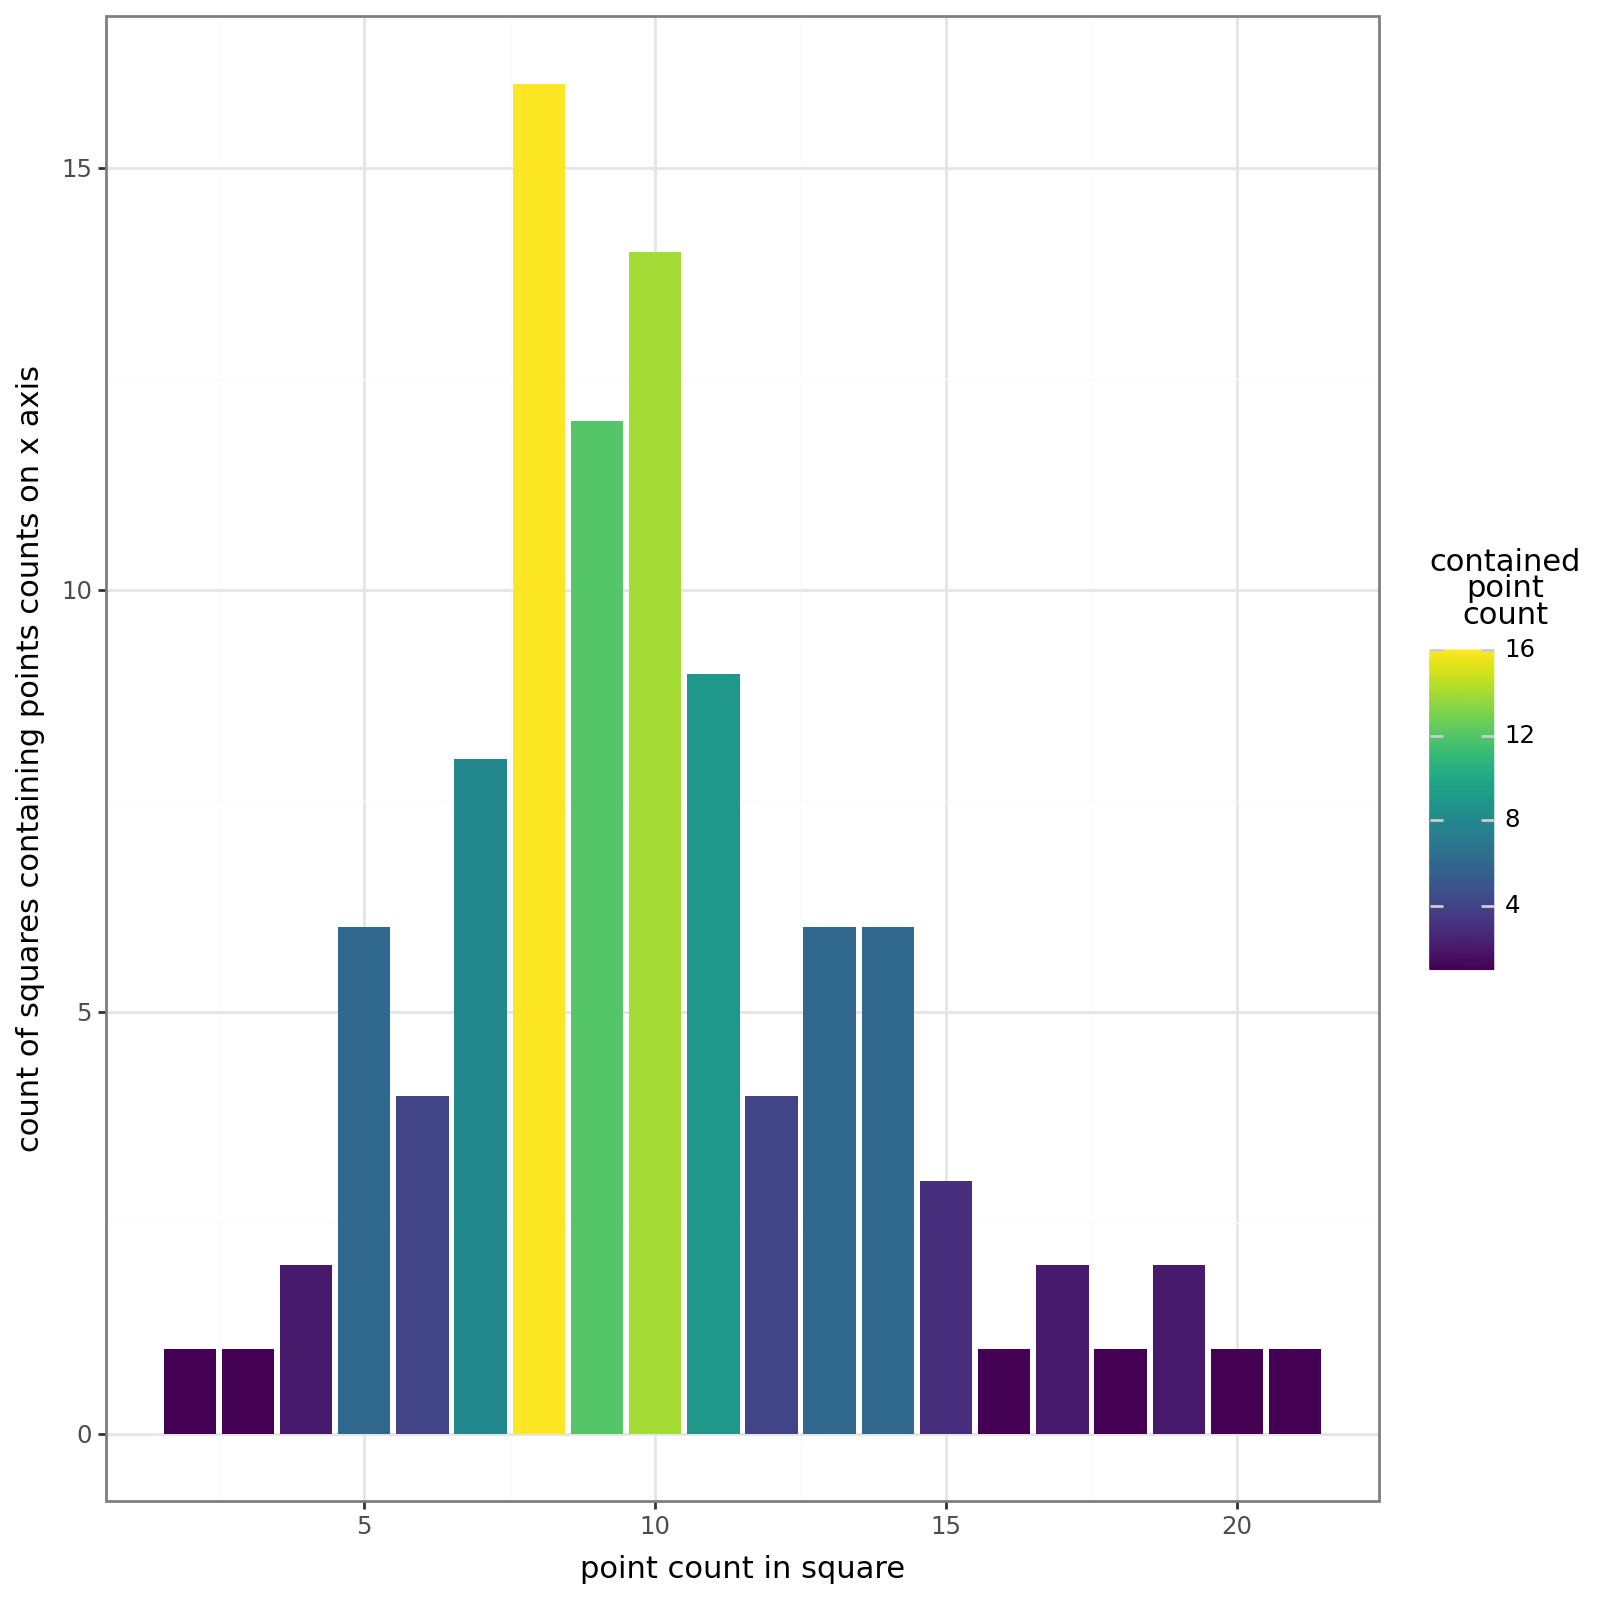

In [38]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_bin_2d(
        mapping=p9.aes(
            x=p9.stage(
                start="x",
                after_stat="unique(count)",
            ),
            y=p9.stage(
                start="y",
                after_stat="my_count_items(count)",
            ),
            fill=p9.after_stat("my_count_items(count)"),
        ),
        geom="col",
        binwidth=0.1,
        size=8,
    )
    + p9.theme_bw()
    + p9.theme(
        figure_size=(8, 8),
    )
    + p9.labs(
        y="count of squares containing points counts on x axis",
        x="point count in square",
        fill="contained\npoint\ncount",
    )
)
plot

-------------------------------

### Regression lines

Finally, the workhorse of plotting - putting regression lines through data points

We create a toy dataset, and fit a linear model

In [39]:
x = np.random.normal(0, 1, size)
y = x + np.random.normal(0, 2, size)


df = pd.DataFrame({"x": x, "y": y})

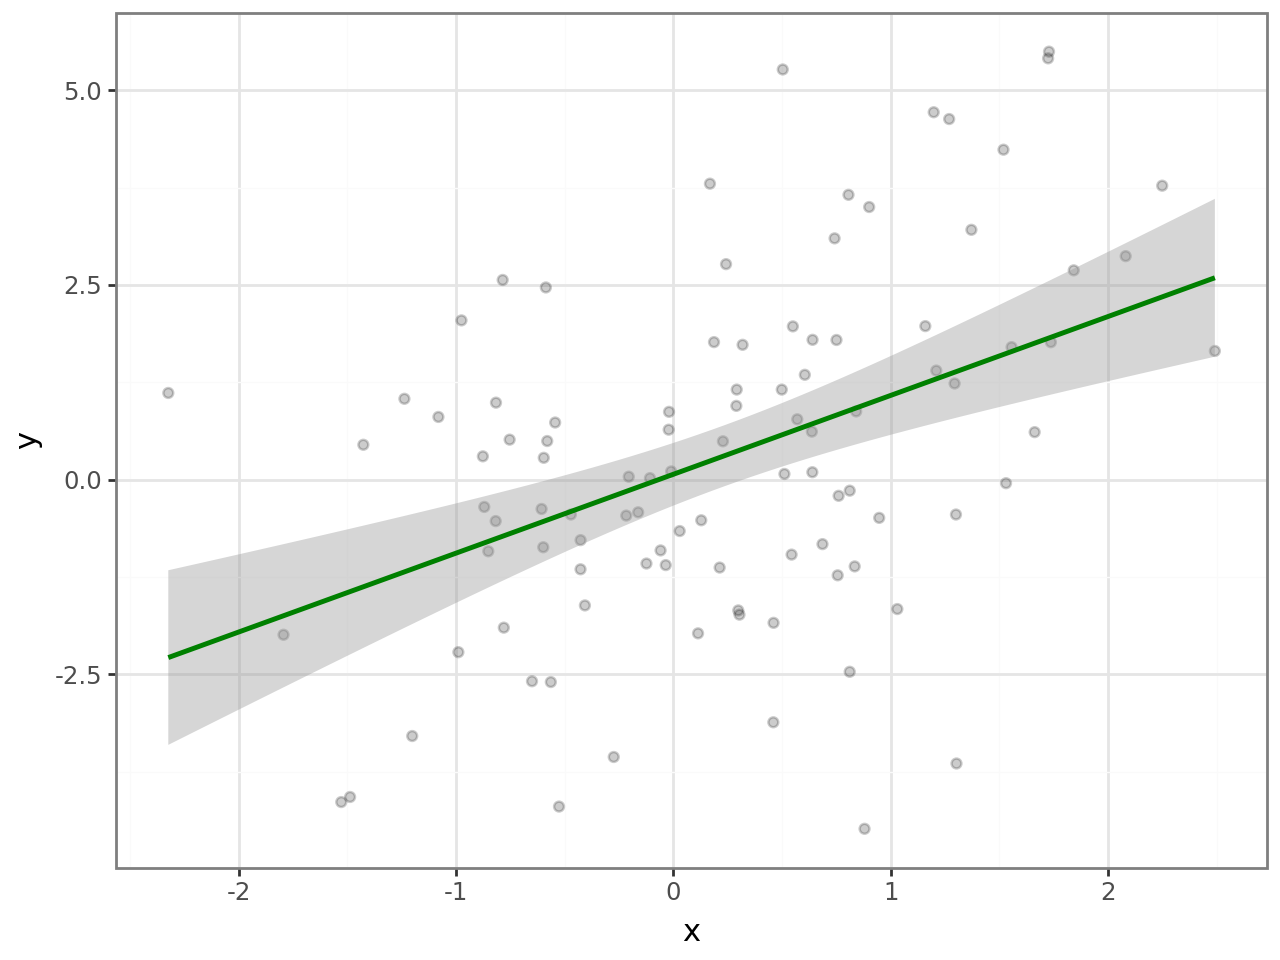

In [40]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(
        mapping=p9.aes(x="x", y="y"),
        alpha=0.2,
    )
    + p9.geom_smooth(mapping=p9.aes(x="x", y="y"), method="glm", color="green")
    + p9.theme_bw()
)
plot

---------------------
## Conclusions

Plotnine is very powerful, with the ability to create statistical processing and visualization pipelines, and also the ability to create a wide range of  usual  graphics with high quality, using very simple calls.  It is now my go-to for plotting purposes.

----------------------

## Reproducability

In [41]:
%watermark

Last updated: 2026-02-26T15:32:41.270837+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [42]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

matplotlib: 3.10.8
numpy     : 2.4.1
pandas    : 2.3.3
plotnine  : 0.15.0
scipy     : 1.16.3



In [43]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: p9_stats
